<a href="https://colab.research.google.com/github/hilarytang02/chinese-lyrics-emotion-classification/blob/main/final-report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chinese Song Classification

### CS156 FINAL PIPELINE

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving lyrics.zip to lyrics.zip


In [ ]:
!unzip lyrics.zip


Archive:  lyrics.zip
   creating: lyrics/
   creating: lyrics/Nostalgic/
  inflating: lyrics/.DS_Store        
  inflating: __MACOSX/lyrics/._.DS_Store  
   creating: lyrics/Hopeful/
   creating: lyrics/Breakup/
   creating: lyrics/Romantic/
  inflating: lyrics/Nostalgic/Hins Cheung_My Way.txt  
  inflating: lyrics/Nostalgic/Lolly Talk_三分甜.txt  
  inflating: lyrics/Nostalgic/易烊千璽_你說.txt  
  inflating: lyrics/Nostalgic/Eason Chan_任我行.txt  
  inflating: lyrics/Nostalgic/Eric Chou_小時候的我們.txt  
  inflating: lyrics/Nostalgic/Dear Jane_到底發生過什麼事.txt  
  inflating: lyrics/Nostalgic/Alfred Hui_微時.txt  
  inflating: lyrics/Nostalgic/Panther Chan_你快樂嗎.txt  
  inflating: lyrics/Nostalgic/Eason Chan_粵語殘片.txt  
  inflating: lyrics/Nostalgic/艾粒_仍然未說的.txt  
  inflating: lyrics/Nostalgic/AGA_無期.txt  
  inflating: lyrics/Nostalgic/Phil Lam_一世同學.txt  
  inflating: lyrics/Nostalgic/Sammi Cheng_再見.txt  
  inflating: lyrics/Nostalgic/Yoyo Sham_風的形狀.txt  
  inflating: lyrics/Nostalgic/Janice Vidal_生涯規劃.txt  

### Intro & data

For this assignment, I am focusing on classifying songs into four emotional/thematic categories based on their lyrics:

- Romantic – Songs about love, devotion, and longing.
- Breakup – Capturing the pain, loss, and emotional aftermath of separation.
- Hopeful – Comforting or encouraging songs that help in difficult times.
- Nostalgic – Songs that evoke memories of youth, growing up, or missing home.

Since Chinese lyrics often rely on metaphors and subtle expressions, I find them particularly beautiful and interesting to analyze. I chose these four themes because they represent the playlists I listen to the most, and they contain the largest number of songs in my collection.

To create a structured dataset of song lyrics, combines data from Spotify and Genius
I start with using Spotify’s API (via the Spotipy library) to extract detailed metadata from my playlists, including track names and artist information.
With this metadata, I then use the Genius API (accessed through the LyricsGenius library) to search for and retrieve the corresponding lyrics for each song.
The lyrics that can be found are saved as individual text files in a dedicated folder called 'lyrics'.

By leveraging these public APIs, we automate the extraction and aggregation of diverse musical content, making the dataset creation process efficient and scalable.
Storing the lyrics locally allows us to apply standard data cleaning and exploratory analysis techniques using libraries like Jieba and pandas.

In [ ]:
!pip install spotipy
!pip install lyricsgenius

import os
import re
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import lyricsgenius

# -----------------------------
# Configure your API credentials
# -----------------------------
SPOTIPY_CLIENT_ID = 'b24b47adb2a94676bb924ab070b186f9'
SPOTIPY_CLIENT_SECRET = 'eb2285b6e27b4d4886b4f1c4ea008671'
SPOTIPY_REDIRECT_URI = 'http://localhost:8888/callback'
SCOPE = 'playlist-read-private'

GENIUS_ACCESS_TOKEN = '1OtAs6c9WU0RNaQHbO2evkUNLJfexp7n9Yjw1UkiMlM9Eier_lYN20odi0gQZfwu'

# -----------------------------
# Initialize the Spotify and Genius client
# -----------------------------
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=SPOTIPY_CLIENT_ID,
    client_secret=SPOTIPY_CLIENT_SECRET,
    redirect_uri=SPOTIPY_REDIRECT_URI,
    scope=SCOPE
))

genius = lyricsgenius.Genius(GENIUS_ACCESS_TOKEN, timeout=15, sleep_time=1)


def fetch_and_save_lyrics(sp, genius, playlist_id, save_folder):
    # Define the parent 'dataset' folder
    dataset_folder = "dataset"

    # Ensure the 'dataset' folder exists
    if not os.path.exists(dataset_folder):
        os.makedirs(dataset_folder)

    # Define the full path where lyrics should be saved
    full_save_folder = os.path.join(dataset_folder, save_folder)

    # Check if the lyrics folder exists in 'dataset'
    if not os.path.exists(full_save_folder):
        os.makedirs(full_save_folder)
        print(f"Created folder: {full_save_folder}")
    else:
        print(f"Folder already exists: {full_save_folder}")

    # Path to store previously searched songs
    searched_songs_file = os.path.join(full_save_folder, "searched_songs.txt")

    # Load previously searched songs into a set
    searched_songs = set()
    if os.path.exists(searched_songs_file):
        with open(searched_songs_file, "r", encoding="utf-8") as f:
            searched_songs = set(line.strip() for line in f)

    # Retrieve tracks from the playlist
    results = sp.playlist_items(playlist_id)
    tracks = results['items']

    # Fetch additional pages if available
    while results['next']:
        results = sp.next(results)
        tracks.extend(results['items'])

    # Create a list to store track metadata
    track_list = []

    print("Retrieving tracks from the Spotify playlist:")
    for item in tracks:
        track = item['track']
        track_name = track['name']
        artist_name = track['artists'][0]['name']  # Taking the first artist for simplicity
        track_list.append({'track_name': track_name, 'artist_name': artist_name})
        print(f" - {track_name} by {artist_name}")

    # Fetch and save lyrics for each track using Genius
    print("\nFetching and saving lyrics for each track:")
    for track in track_list:
        track_name = track['track_name']
        artist_name = track['artist_name']

        # Generate a unique key for tracking searches
        song_key = f"{artist_name} - {track_name}"

        # Skip if the song was already searched
        if song_key in searched_songs:
            print(f"Already searched '{track_name}' by {artist_name}. Skipping.")
            continue

        # Sanitize the filename by removing illegal characters
        safe_track_name = re.sub(r'[\\/*?:"<>|]', "", track_name)
        safe_artist_name = re.sub(r'[\\/*?:"<>|]', "", artist_name)
        filename = os.path.join(full_save_folder, f"{safe_artist_name}_{safe_track_name}.txt")

        try:
            # Search for the song on Genius
            song = genius.search_song(track_name, artist_name)

            # Log the search attempt
            with open(searched_songs_file, "a", encoding="utf-8") as f:
                f.write(song_key + "\n")

            if song:
                # Check if the lyrics contain at least one Chinese character
                if not re.search(r'[\u4e00-\u9fff]', song.lyrics):
                    print(f"'{track_name}' by {artist_name} does not appear to be in Chinese. Skipping.")
                    continue
                with open(filename, "w", encoding="utf-8") as f:
                    f.write(song.lyrics)
                print(f"Saved lyrics for '{track_name}' by {artist_name} to {filename}")
            else:
                print(f"Lyrics not found for '{track_name}' by {artist_name}.")
        except Exception as e:
            print(f"Error retrieving lyrics for '{track_name}' by {artist_name}: {e}")

In [ ]:
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:5xyY8qvuTT3bu7I4EZrrK8', "Hopeful")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:26wLPbk8pEGACMWLLQ6zAo', "Breakup")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:5NnmaHZisIOkTSQHrQySkN', "Breakup")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:4Vh7HQNrLVxLTTlHU2HD9G', "nostalgic")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:4wMV6VuktylzFKffYR0NCs', "nostalgic")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:1PVFBy9S4DaoKBwwDydlcg', "Romantic")

Created folder: dataset/Hopeful


KeyboardInterrupt: 

While building the dataset, I noticed that Genius did not have lyrics for many Chinese songs—particularly in the “breakup” and “nostalgia” categories. This shortage resulted in an unbalanced dataset, as these categories ended up underrepresented. To address this, I added more songs to increase the total number of samples and to ensure each category is more evenly represented. By expanding the dataset in this way, I aim to provide a more balanced and comprehensive collection of lyrics, which is crucial for training robust classification models.

In [ ]:
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:1N1fFRBzsWliaZper3WB9F', "Breakup")
fetch_and_save_lyrics(sp, genius, 'spotify:playlist:0D3ObU8Bq3FWy7aHjayLf9', "Nostalgic")

### Data Ingestion and Cleaning

In [ ]:
import os
import pandas as pd
import glob

def load_lyrics_data(root_folder="lyrics"):
    """
    Loads song lyrics from text files stored in category-based subfolders.
    """
    data = []
    for category in os.listdir(root_folder):
        folder = os.path.join(root_folder, category)
        if os.path.isdir(folder):
            for filepath in glob.glob(os.path.join(folder, "*.txt")):
                with open(filepath, 'r', encoding='utf-8') as file:
                    lyrics = file.read().strip()
                data.append({
                    "filename": filepath,
                    "lyrics": lyrics,
                    "label": category
                })

    return pd.DataFrame(data)

df = load_lyrics_data()
print("Loaded data:")
print(df.head())

Loaded data:
                                     filename  \
0              lyrics/Romantic/Yokez_你的出现.txt   
1  lyrics/Romantic/Eric Chou_This is love.txt   
2       lyrics/Romantic/Dear Jane_不許你注定一人.txt   
3            lyrics/Romantic/陳卓賢 Ian_DWBF.txt   
4           lyrics/Romantic/Pakho Chau_宏願.txt   

                                              lyrics     label  
0  1 Contributor你的出现 (How You Appeared) Lyrics凌晨一...  Romantic  
1  1 ContributorThis Is Love Lyrics你手靠近了 卻又放下\n牽著...  Romantic  
2  2 Contributors不許你注定一人 (Never Be Alone) Lyrics[...  Romantic  
3  3 ContributorsDWBF Lyrics[Ian 陳卓賢「DWBF」歌詞]\n\n...  Romantic  
4  1 Contributor宏願 (Small Wish) Lyrics明知 殘酷亦只可以面對...  Romantic  


Since I've been curating these playlists since 2019, it's possible that I've experienced different emotions for the same song over time, leading me to place it in multiple mood-based folders. To ensure that the categorization remains consistent and that no single song unduly influences any category, I decided to remove duplicate entries from the dataset. This process involved identifying songs with the same file name (indicating they are the same track) across all folders and removing all instances of duplicates. As a result, each song appears only once in the dataset, maintaining clear and distinct boundaries between categories.

In [ ]:
# Check for duplicate file names across categories and remove all duplicates
df['basename'] = df['filename'].apply(lambda x: os.path.basename(x))
# Create a boolean mask where True indicates a duplicate (appearing more than once)
duplicates_mask = df['basename'].duplicated(keep=False)

if duplicates_mask.any():
    print("Duplicated file names found. Removing all instances of these duplicates:")
    print(df.loc[duplicates_mask, 'basename'].value_counts())
    # Keep only rows that are not duplicates
    df = df[~duplicates_mask]
else:
    print("No duplicated text file names found across categories.")

Duplicated file names found. Removing all instances of these duplicates:
basename
Cloud 雲浩影_無以名狀的痛.txt       2
Joyce Cheng_我所看見的未來.txt    2
MIRROR_We All Are.txt      2
Dear Jane_到底發生過什麼事.txt     2
Name: count, dtype: int64


To increase the size and granularity of my dataset, I applied a data augmentation technique known as shingling, where each song's lyrics were split into overlapping mini-segments of two lines each. This approach preserves more contextual continuity than single-line splitting, while still significantly expanding the number of training samples. Each two-line shingle inherits the label of the original song (e.g., Breakup, Hopeful), enabling the model to learn from more localized emotional cues within the lyrics. By augmenting in this way, I was able to boost the dataset from 184 full-length songs to over 18,000 labeled text samples, which provides a much richer dataset for training.

In [ ]:
def augment_by_shingles(df, min_line_length=5, lines_per_shingle=2):
    """
    Augments the dataset by grouping lyrics into mini-verses of N lines.

    Parameters:
    - df: original DataFrame with 'lyrics' and 'label'
    - min_line_length: minimum length of a line to include in a shingle
    - lines_per_shingle: how many lines per text unit (default = 2)

    Returns:
    - A new DataFrame with columns ['shingle', 'label']
    """
    rows = []
    for _, row in df.iterrows():
        label = row['label']
        lines = [line.strip() for line in row['lyrics'].split('\n') if len(line.strip()) >= min_line_length]

        # Group into shingles (e.g., every 2 or 3 lines)
        for i in range(0, len(lines) - lines_per_shingle + 1):
            shingle = "\n".join(lines[i:i + lines_per_shingle])
            rows.append({'shingle': shingle, 'label': label})

    return pd.DataFrame(rows)

df_shingled = augment_by_shingles(df, min_line_length=5, lines_per_shingle=2)

print("Preview of shingled data:")
print(df_shingled.head())

print("Label distribution:")
print(df_shingled['label'].value_counts())


Preview of shingled data:
                                             shingle     label
0  1 Contributor你的出现 (How You Appeared) Lyrics凌晨一...  Romantic
1                            眼裡都是你 你的笑顏\n總是裝模作樣卻傻得特別  Romantic
2                             總是裝模作樣卻傻得特別\n我就是喜歡你的這點  Romantic
3                              我就是喜歡你的這點\n茫茫人群中 你的出現  Romantic
4                             茫茫人群中 你的出現\n平淡的日子 不再討厭  Romantic
Label distribution:
label
Romantic     5798
Breakup      4689
Hopeful      4373
Nostalgic    3845
Name: count, dtype: int64


After inspecting the dataset, it became clear that the four mood categories—“inlove,” “breakup,” “comforting,” and “nostalgia”—are not equally represented. For instance, 'romantic' have 2000 more lines than “nostalgia.” This imbalance can skew the model, causing it to favor the overrepresented categories. Although I attempted to add more songs to the underrepresented categories, there is no guarantee that Genius can find lyrics for all of them, which further complicates the issue.

To handle this, I decided to construct a balanced dataset by using an undersampling approach. Specifically, I reduced each category to match the size of the smallest category. This ensures that each label has the same number of samples, preventing the model from overfitting to any single category and improving the overall reliability of the classification.

In [ ]:
from sklearn.utils import resample

def balance_dataset(df, method="undersample"):
    """
    Balances the dataset so that all categories have the same number of samples.
    Options:
    - "undersample": Reduce larger categories to match the smallest one.
    - "oversample": Increase smaller categories to match the largest one.
    """
    if df.empty:
        print("Dataset is empty. Nothing to balance.")
        return df

    category_counts = df['label'].value_counts()
    min_samples = category_counts.min()
    max_samples = category_counts.max()

    if method == "undersample":
        # Reduce all categories to match the smallest one
        df_balanced = df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), min_samples), random_state=42))
    elif method == "oversample":
        # Increase all categories to match the largest one
        df_balanced = df.groupby('label', group_keys=False).apply(lambda x: resample(x, replace=True, n_samples=max_samples, random_state=42))
    else:
        raise ValueError("Invalid balance method. Choose 'undersample' or 'oversample'.")

    return df_balanced.reset_index(drop=True)

df_balanced = balance_dataset(df_shingled, method="undersample")
print("Balanced dataset:")
print(df_balanced['label'].value_counts())


Balanced dataset:
label
Breakup      3845
Hopeful      3845
Nostalgic    3845
Romantic     3845
Name: count, dtype: int64


<ipython-input-16-9be1bc0dcc71>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), min_samples), random_state=42))


The Jieba library is a Python tool designed specifically for Chinese text segmentation.
It provides an efficient and accurate way to break continuous Chinese text into meaningful words for natural language processing (NLP) tasks.
In projects involving Chinese language data like this, Jieba helps convert raw, unsegmented text into a tokenized format that is suitable for further analysis with machine learning.

One of Jieba's strengths is its ease of use and its ability to handle the unique challenges posed by the Chinese language, where words are not separated by spaces.
It employs both dictionary-based methods and statistical algorithms to ensure accurate segmentation.
Although it might not offer the extensive suite of tools available in libraries like NLTK for English text processing,
Jieba is highly effective for Chinese text and integrates well into workflows that require quick and reliable tokenization for downstream NLP tasks.

The preprocess_lyrics_chinese function transforms raw Chinese song lyrics into a clean, standardized, and tokenized format ready for feature extraction.
Each step in the process is designed to remove noise, ensure consistency, and prepare the text for effective downstream analysis.

1. Splitting and Header Removal:
When the lyrics is downloaded from genius, it contains a header that signifies the contributor and the title of the song.
To eliminate any extraneous information or metadata (such as titles or headers) that do not contribute to the core lyrical content, this step split the lyrics into individual lines to identigy and remove the header, ensuring that only the main body of the lyrics is processed.

2. Annotation Removal:
The downloaded lyrics also contains annotations (e.g., [Chorus]), and they are not part of the actual lyrical content.
Removing them helps focus the analysis on the meaningful words and phrases within the song.

3. Rejoining and Punctuation Removal:
The filtered lines are rejoined into a single string, and both Chinese and English punctuation (e.g., commas, periods, exclamation points, parentheses) are removed.
Since punctuation can interfere with tokenization and analysis by creating unnecessary splits or symbols, removing punctuation creates a smoother text flow for processing.

4. Conversion from Simplified to Traditional Chinese:
The cleaned text is converted from Simplified to Traditional Chinese using OpenCC.
This help standardizing the dataset to ensure that words with the same meaning but different character forms are treated uniformly, allowing accurate tokenization and frequency analysis.

5. Tokenization:
Tokenization is the process of splitting a string of text into individual words or tokens.
This breaks down the lyrics into manageable units, which is crucial for subsequent steps like filtering and frequency analysis.
Chinese text does not naturally separate words with spaces, and the standardized text is tokenized using the jieba library.

6. Stopword Filtering:
Stopwords are common words that add little semantic value, and they can dilute the significance of the analysis. Tokens are filtered to remove common stopwords, so that the model can focus on the more informative words that are more indicative of the song's themes and content.

7. Filtering by Character Content:
Any token that does not contain at least one Chinese character is removed. This final filtering ensures that the analysis only includes relevant Chinese words, further reducing noise and improving the quality of the token set.

After these preprocessing, the tokens are rejoined into a space-separated string, which is a format well-suited for feature extraction, any subsequent machine learning or text analysis tasks.

In [ ]:
import requests

# URL of the Chinese stopwords file (raw file from GitHub)
url = "https://raw.githubusercontent.com/goto456/stopwords/master/cn_stopwords.txt"

# Send a GET request to the URL
response = requests.get(url)

# Check if the download was successful
if response.status_code == 200:
    # Save the content to a file named "chinese_stopwords.txt"
    with open("chinese_stopwords.txt", "w", encoding="utf-8") as f:
        f.write(response.text)
    print("Downloaded Chinese stopwords successfully!")
else:
    print(f"Failed to download Chinese stopwords. Status code: {response.status_code}")

Downloaded Chinese stopwords successfully!


In [ ]:
!pip install opencc

import jieba
import opencc

# Convert from Simplified to Traditional Chinese
converter = opencc.OpenCC('s2t')

def load_chinese_stopwords(filepath):
    """
    Loads Chinese stopwords from a file.
    Assumes one stopword per line.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        stopwords = set(f.read().split())
    return stopwords

# Load Chinese stopwords from your provided file.
chinese_stopwords = load_chinese_stopwords("chinese_stopwords.txt")

def preprocess_lyrics_chinese(text):
    """
    Preprocess Chinese lyrics by:
    1. Splitting text into lines and optionally discarding a header.
    2. Removing lines with annotations in square brackets (e.g., [Chorus]).
    3. Rejoining the text and removing common Chinese and English punctuation.
    4. Converting text from simplified to traditional Chinese.
    5. Tokenizing using jieba.
    6. Removing stopwords.
    7. Filtering out tokens that do not contain Chinese characters.
    Returns a space-separated string for feature extraction.
    """
    # 1. Split text into lines; remove header if needed
    lines = text.split('\n')
    if len(lines) > 0:
        lines = lines[1:]  # adjust if header is to be discarded

    # 2. Remove lines with annotations like [Chorus]
    filtered_lines = [line for line in lines if not re.search(r'\[.*?\]', line)]

    # 3. Rejoin into a single string
    cleaned_text = ' '.join(filtered_lines)

    # 4. Remove punctuation: expand to include parentheses and common English punctuation
    punctuation_pattern = r'[，。！？、；：“”‘’《》,!?.:;\'"()\[\]<>-]'
    cleaned_text = re.sub(punctuation_pattern, '', cleaned_text, flags=re.UNICODE)

    # 5. Convert simplified Chinese to traditional Chinese
    cleaned_text = converter.convert(cleaned_text)

    # 6. Tokenize using jieba
    tokens = jieba.lcut(cleaned_text)

    # 7. Remove stopwords
    tokens = [word for word in tokens if word not in chinese_stopwords]

    # 8. Filter tokens: keep only tokens that contain at least one Chinese character
    tokens = [word for word in tokens if re.search(r'[\u4e00-\u9fff]', word)]

    return " ".join(tokens)


# Apply preprocessing
df_balanced['processed'] = df_balanced['shingle'].apply(preprocess_lyrics_chinese)
df_balanced['processed'] = df_balanced['processed'].fillna('').astype(str)
print("\nPreprocessed text sample:")
print(df_balanced[['label', 'processed']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.7 MB/s eta 0:00:00


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.997 seconds.
DEBUG:jieba:Loading model cost 0.997 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.



Preprocessed text sample:
     label      processed
0  Breakup   不愛我 不用 問心 有愧
1  Breakup       恨 捱 夠 折磨
2  Breakup  討厭 今天 沒 理由 道歉
3  Breakup    確切 愛過 勝過 一對
4  Breakup     變得 沒 那麼 幼稚


### Exploratory Data Analysis

I computed the number of tokens for each song to get an idea of text length and processing success.
Additionally, I visualize the distribution of token counts and compute the most common words across the dataset to understand the general vocabulary and dominant themes present in the lyrics, as well as confirm that the cleaning steps retain relevant content.


Descriptive Statistics:
count    15380.000000
mean         3.669441
std          2.209248
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         13.000000
Name: num_tokens, dtype: float64


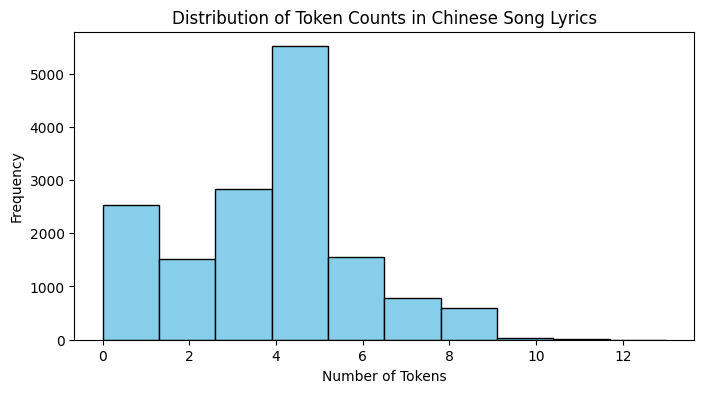


Most Common Words in the Chinese Lyrics Dataset:
說: 526
誰: 462
我們: 370
後: 367
想: 332
讓: 311
會: 308
愛: 307
於: 292
著: 285


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Calculate token counts per song (assuming tokens are separated by spaces)
# Convert non-string values or NaNs to an empty string


df_balanced['num_tokens'] = df_balanced['processed'].apply(lambda x: len(x.split()))
print("\nDescriptive Statistics:")
print(df_balanced['num_tokens'].describe())

# Plot token count distribution
plt.figure(figsize=(8, 4))
plt.hist(df_balanced['num_tokens'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Token Counts in Chinese Song Lyrics")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

# Find most common words across all songs
all_tokens = [token for processed in df_balanced['processed'] for token in processed.split()]
word_counts = Counter(all_tokens)
common_words = word_counts.most_common(10)
print("\nMost Common Words in the Chinese Lyrics Dataset:")
for word, count in common_words:
    print(f"{word}: {count}")

The histogram shows the distribution of token counts per shingle in the Chinese lyrics dataset. Most lyric segments contain between 2 and 5 tokens, with a median of 4. The distribution is slightly right-skewed, indicating that shorter segments dominate the dataset.
While most lyric segments contain only 2–5 tokens, this brevity mirrors the structure of Chinese pop lyrics, where emotion and meaning are often conveyed in highly condensed language.
This insight is important for model preprocessing, as it suggests that padding or truncation thresholds should be kept relatively short (e.g., under 10 tokens) to preserve the natural structure of the data without excessive padding.

The most frequently occurring words in the dataset include:
說 (say), 誰 (who), 我們 (we/us), 後 (after), 想 (think/want), 會 (will), 讓 (let), 讓 (need), 於 (at), and 對 (toward/right). These commonly used words highlight recurring themes in Chinese lyrics:

- 說, 誰, and 想 reflect a conversational or introspective tone, often centered on communication and emotional reflection.

- 後 and 於 suggest temporal or spatial movement, resonating with themes of change, memory, or longing.

- 我們 indicates frequent use of first-person plural perspective, reinforcing the relational or communal nature of many lyrics.

- 會 and 讓 point toward themes of aspiration, choice, and agency—common across romantic, nostalgic, and hopeful songs.

Given the nature of Chinese as a language without explicit word boundaries, token segmentation significantly influences these frequency counts. Some frequent words—while not strictly grammatical stopwords—may still contribute limited semantic value in classification tasks. This calls for a carefully curated stopword list tailored to the dataset’s genre and purpose.

Additionally, high-frequency words may be disproportionately represented in song choruses due to repetition. Without accounting for structure, this could bias models toward surface-level patterns. Differentiating between verses and choruses, or incorporating bigrams and contextual models (e.g., BERT), could help preserve thematic nuance and reduce overfitting to repetitive tokens like “說” or “對.”

### Naive Bayes

My objective is to predict which category a song belongs to (comforting, nostalgia, breaking up, or love) based on its lyrics.

This is a classification problem because the output is a discrete label chosen from a fixed set of categories.

After balancing and preprocessing the dataset, the data is seperated into training set and test set. This allows for the evaluation of how well the model generalizes to new, unseen data.

The training set help the model to learn patterns and relationships in the lyrics that distinguish one category from another.
Here, it contains 80% of samples from the entire dataset.

As for the test set, the key idea is that the model does not see these samples during training.
After the model is trained, it is evaluated on the data in test set to gauge how well it can predict the correct category for songs it has never encountered before.
Here, the remaining 20% of the data is reserved for test set.

The training set is deliberately made larger, so that the model has enough examples to learn from.
At the same time, it is also important to have a sufficiently sized test set to provide a reliable estimate of how the model will perform on real-world data.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Explanation:
# X_nb contains the processed lyrics (text transformed to a space-separated string after segmentation).
# y_nb contains the corresponding labels (categories such as comforting, growing up, breaking up, love).
# Extract features and labels.
X_nb = df_balanced['processed']  # List of text documents
y_nb = df_balanced['label']      # Class labels as a NumPy array

# We use train_test_split to create a training set and a test set.
# The test_size parameter is set to 0.2, meaning 20% of the data is reserved for testing.
# random_state is set for reproducibility.
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=42)

# Output the size of each split to confirm
print("Total samples:", len(df_balanced))
print("Training samples:", len(X_train_nb))
print("Test samples:", len(X_test_nb))

Total samples: 15380
Training samples: 12304
Test samples: 3076


Although the sample size is small, it meets the criteria of having training samples in the hundreds and test samples in the tens.
In future assignments, I can increase the dataset size to improve model performance.



Naive Bayes is a probabilistic classifier based on Bayes' Theorem. Bayes' Theorem is a way to update our beliefs based on new evidence. It tells us how likely a particular class is (for example, "breakup" or "inlove" for a song) given the observed words in the lyrics.

Bayes' Theorem:

$P(C_k \mid x) = \frac{P(x \mid C_k) \, P(C_k)}{P(x)}$   

where

- $P(C_k \mid x)$ refers to the probability that a song belongs to class $C_k $ (e.g., "breakup") given the lyrics $x$
- $P(x \mid C_k)$ refers to the likelihood of observing the lyrics  $x$ if we already knew the song was in class $C_k$
- $P(C_k)$ refers to the prior of how common class $C_k$ is (for example, in this case, the classes are balanced, 25% of our songs are breakup songs, then P(breakup)=0.25).
- $P(x)$ refers to the normalizing constant ensuring that the probabilities for all classes add up to 1.

Because we assume that the tokens are conditionally independent given the class, we can simplify the likelihood $P(x \mid C_k)$ as:

$P(x \mid C_k) \approx \prod_{i=1}^{n} P(x_i \mid C_k)$

where $x_i$ represents the i-th token in the lyrics.

Since we want choose the class $C_k$ that maximizes posterior probability (i.e., the product of the prior probability and the likelihoods of all the tokens given that class), the final prediction:

$\hat{y} = \arg\max_{k} \, P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k)$




The term "naive" here refers to the simplified ("naive") assumptions for the model, which is the assumption that all tokens (features) are conditionally independent given the class label.
As words in a sentence influence each other, this assumption is an oversimplificiation.
However, Naive Bayes is generally still regard as a strong baseline for text classification because it provides a reasonable approximation that performs well in practice.

For this project, Multinomial Naive Bayes is chosen over Gaussian Naive Bayes due to the nature of the feature representation.
Multinomial Naive Bayes assumes that features (i.e. TF–IDF scores) are generated from a multinomial distribution; whereas, Gaussian Naive Bayes assumes that features follow a normal distribution, which is more appropriate for continuous numerical data.

While TF–IDF values are continuous, they tend to be sparse and skewed and do not follow a Gaussian distribution. So, Gaussian Naive Bayes would not be as effective in this case.
Multinomial Naive Bayes, despite being originally designed for discrete count data, has been widely used for TF–IDF-based text classification.


In [ ]:
# --------------------------
# Pseudocode for Naive Bayes Classification
# --------------------------
# Given a document x represented as TF-IDF features:
#
# For each class C_k in the set of possible classes:
#     Compute the prior probability P(C_k) from the training data.
#     For each feature x_i in the document x:
#         Compute the likelihood P(x_i | C_k).
#     Compute the posterior probability:
#         P(C_k | x) ∝ P(C_k) * Π (over i) P(x_i | C_k)
#
# Predict the class that maximizes the posterior probability:
#     y_pred = argmax_k P(C_k | x)
#
# This is essentially what the MultinomialNB implementation does under the hood.

# The nb_pipeline is now ready to be trained on the dataset.
# For example, if X_train contains the song lyrics and y_train contains the corresponding labels,
# you would train the model as follows:
# nb_pipeline.fit(X_train, y_train)

# After training, predictions can be made with:
# y_pred = nb_pipeline.predict(X_test)

#### TF-IDF

In classification tasks, the input data is represented numerically, because most machine learning algorithms work with numerical vectors rather than raw text.
This allows models to detect patterns and associations between word usage and the song’s category, apply learned weights to new, unseen tokens, and use optimization like gradient descent on continuous numerical data.

To convert to numbers, For naive bayes we are using Term Frequency–Inverse Document Frequency (TF‑IDF).

TF‑IDF is used to quantify the importance of a token in a song relative to the entire dataset.
It helps to weigh down common words while highlighting words that are more distinctive.
For a token $t$ in a document (i.e., a song's lyrics) $d$, TF‑IDF is computed as:

$TF-IDF(t,d)=TF(t,d)×IDF(t,D)$,

where:

Term Frequency $\text{TF}(t, d)$ measures how often a token appears in the lyrics of a song, normalized by the total length of the document.
A higher TF indicates the term is more significant within that document.

$\text{TF}(t, d) = \frac{\text{count}(t, d)}{\sum_{t' \in d} \text{count}(t', d)} = \frac{\text{the number of times a token appears in the song}}{\text{the total number of tokens in the song}}$

Inverse Document Frequency measures how “unique” or “rare” a token is across the entire dataset.
If a token appears in many songs, the ratio inside the logarithm is smaller, leading to a lower IDF value is lower.
This reduces the weight of very common words.

$\text{IDF}(t, D) = \log \left( \frac{N}{\left|\{\,d' \in D : t \in d'\}\right|} \right) = \frac{\text{the total number of songs in the entire dataset}}{\text{ the number of songs in which the token appears.}}$


As such, TF emphasizes how important a term is in a particular document, while IDF downweights terms that appear frequently across many documents.

As a result, the text is transformed into a vector where each component represents the TF‑IDF value of a specific term.
This fixed-length vector can be fed into traditional classifiers like Naive Bayes or MLP.

TF-IDF is chosen over simple word count (i.e., raw frequency) because firstly, raw frequency assigns a higher importance to terms that appear frequently in longer documents, even if those terms are not particularly meaningful.
TF-IDF normalizes term frequency by the total number of words in a document, ensuring that longer lyrics do not automatically have an inflated weight for common words.
Secondly, it also helps reduce the impact of common words. For example, in a lyrics dataset, frequently occurring words would dominate classification if simple word count were used.
TF-IDF reduces the weight of such commonly occurring words across many songs while emphasizing distinctive words that help differentiate song categories (e.g., "童年 (childhood)" for nostalgic).

In [ ]:
# Import necessary modules from scikit-learn
from sklearn.pipeline import Pipeline                     # For chaining preprocessing and modeling steps
from sklearn.feature_extraction.text import TfidfVectorizer  # For converting text into TF-IDF feature vectors
from sklearn.naive_bayes import MultinomialNB              # For the Naive Bayes classifier
from sklearn.metrics import classification_report           # For model evaluation

# --------------------------
# Naive Bayes Pipeline Setup
# --------------------------
# This pipeline consists of two main steps:
# 1. 'tfidf': Converts raw text (song lyrics) into numerical TF-IDF features.
#    - max_features=5000 limits the feature space to the top 5000 terms, reducing noise and computational cost.
# 2. 'clf': Applies the Multinomial Naive Bayes classifier on the TF-IDF features.
#    - MultinomialNB is well-suited for text data and works by estimating the probability of each class
#      based on the frequency of features (words) in the training data.

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),  # Step 1: Text to TF-IDF vector conversion.
    ('clf', MultinomialNB())                         # Step 2: Naive Bayes classification.
])

# Training models
nb_pipeline.fit(X_train_nb, y_train_nb)

# Naive Bayes predictions
y_pred_nb = nb_pipeline.predict(X_test_nb)
print("Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

     Breakup       0.72      0.65      0.68       774
     Hopeful       0.72      0.52      0.60       758
   Nostalgic       0.75      0.56      0.64       803
    Romantic       0.49      0.82      0.62       741

    accuracy                           0.63      3076
   macro avg       0.67      0.64      0.64      3076
weighted avg       0.67      0.63      0.64      3076



#### Building TD-IDF and Naive Bayes Model from scratch

To further my understanding of the model's mechanism and code, I built the Naive Bayes text classifier from scratch.
This version manually computes class priors and conditional probabilities without relying on external scikit-learn’s built-in Naive Bayes libraries.

The classifier is specifically designed to work with TF-IDF features instead of raw word counts, meaning that instead of treating term frequencies as direct feature counts, it scales features based on their informativeness across the dataset.
This avoids giving too much weight to highly frequent but uninformative words and instead prioritizes words that uniquely characterize a given class.
The way this is achieved in the model is through computing conditional probabilities not over raw counts of words, but over the sum of TF-IDF scores per class.
As a result, the probability of a word in a class depends on its weighted presence rather than simple occurrence frequency.

During training (fit method), it begins by computing class prior probabilities $P(c)$, which represent how frequently each class appears in the dataset.
Next, for each class, the TF-IDF values of all documents belonging to that class are summed to create a representation of feature importance per class.
Laplace smoothing is applied to prevent zero probabilities for unseen words.
This is necessary because, in probabilistic models, a zero probability for any feature (word) in a class would cause the entire class probability computation to be zero when using multiplication (or negative infinity when working with log probabilities).
To prevent this, we add a small constant $\alpha = 1$ to every probability calculation.
Choosing $\alpha = 1$ represents "add-one smoothing," which ensures that every feature has at least some probability mass, avoiding division by zero issues and preventing extreme biases in classification.
While alternative values for $\alpha$ (e.g., 0.1 or 10) could be used to fine-tune the degree of smoothing, $\alpha = 1$ is a commonly used default that balances smoothing without overly distorting word importance.
The model then normalizes these smoothed values to obtain the conditional probability $P(feature∣c)$, which estimates the likelihood of each word given a class.

During prediction (predict method), the model evaluates each document by computing the log probability of belonging to each class.
This is done by summing the log prior probability $logP(c)$ and the weighted sum of log conditional probabilities $\sum_{j} \text{TF-IDF}_j \cdot \log P(\text{word}_j \mid c)$.
This formulation means that words with higher TF-IDF scores in a document contribute more significantly to the final probability of a class, emphasizing distinguishing terms rather than common stopwords.
The class with the highest computed probability is chosen as the predicted label.
This approach ensures that the model effectively balances prior knowledge of class distributions with the importance of words in each document.

One strength of implementing Naive Bayes from scratch is the flexibility it offers for customization.
For example, in this implementation, the way conditional probabilities are computed has been modified to work specifically with TF-IDF rather than raw word counts.
Additionally, the smoothing parameter $\alpha$ is explicitly set, allowing for experimentation with different values to observe their effects on classification.

Another area of customization is in how probabilities are computed: instead of working in the traditional count-based space, we modify the denominator of the probability calculation to normalize by the total TF-IDF sum per class, ensuring the model properly accounts for the weighted nature of TF-IDF features. This level of control allows further optimizations, such as adjusting how much TF-IDF weight should influence probability calculations, or modifying how log probabilities are aggregated.

In [ ]:
# Custom Naive Bayes classifier built from scratch
class CustomNaiveBayes:
    def __init__(self, alpha=1.0):
        """
        Initialize the classifier with a smoothing parameter.

        :param alpha: Laplace smoothing parameter to avoid zero probabilities.
        """
        self.alpha = alpha               # Laplace smoothing parameter
        self.class_priors = {}           # Dictionary to store prior probabilities for each class
        self.feature_prob = None         # Conditional probability matrix: shape (n_classes, n_features)
        self.classes = None              # Array of unique class labels

    def fit(self, X, y):
        """
        Train the Naive Bayes classifier using the provided TF-IDF feature matrix and labels.

        :param X: TF-IDF feature matrix (sparse matrix) where rows correspond to documents.
        :param y: Array-like of class labels for each document.
        """
        # Get the total number of documents and features
        n_docs, n_features = X.shape

        # Identify the unique classes and count how many there are
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Compute prior probabilities for each class: P(c) = (# documents in class c) / (total documents)
        self.class_priors = {c: np.sum(y == c) / float(n_docs) for c in self.classes}

        # Initialize an array to accumulate the sum of TF-IDF values per feature for each class.
        # This array has shape (n_classes, n_features)
        feature_sum = np.zeros((n_classes, n_features))

        # Loop over each class and sum the TF-IDF values for documents that belong to that class.
        for idx, c in enumerate(self.classes):
            # Get indices of documents that belong to class c
            indices = np.where(y == c)[0]
            # Sum the TF-IDF values along the document axis for class c
            # Convert the result to a flat array
            feature_sum[idx, :] = np.array(X[indices].sum(axis=0)).flatten()

        # Apply Laplace smoothing: add alpha to each "feature count" (here, weighted by TF-IDF)
        smoothed_fc = feature_sum + self.alpha

        # Compute the total sum of TF-IDF values per class after smoothing
        class_feature_sum = smoothed_fc.sum(axis=1)  # shape: (n_classes,)

        # Calculate the conditional probability for each feature given the class:
        # P(feature | class) = (smoothed TF-IDF count for feature) / (total smoothed TF-IDF count for class)
        self.feature_prob = smoothed_fc / class_feature_sum[:, np.newaxis]

    def predict(self, X):
        """
        Predict class labels for the given TF-IDF feature matrix.

        :param X: TF-IDF feature matrix (numpy array) for test documents.
        :return: Numpy array of predicted class labels.
        """
        predictions = []
        # Iterate over each document in the test set
        for i in range(X.shape[0]):
            # Directly use the row if X is a NumPy array
            # If it's sparse, you could use X[i].toarray().flatten()
            x_i = X[i, :].flatten()
            log_probs = []

            # Compute the log probability for each class for this document.
            for idx, c in enumerate(self.classes):
                log_prob = np.log(self.class_priors[c])
                log_prob += np.sum(x_i * np.log(self.feature_prob[idx, :]))
                log_probs.append(log_prob)

            # The predicted class is the one with the highest computed log probability.
            predictions.append(self.classes[np.argmax(log_probs)])
        return np.array(predictions)



In [ ]:
import math

class CustomTfidfVectorizer:
    def __init__(self,
                 max_features=None,
                 norm='l2',
                 sublinear_tf=False,
                 token_pattern=r'(?u)\b\w\w+\b'):
        """
        A custom TF-IDF vectorizer that approximates scikit-learn's defaults.

        :param max_features: Maximum number of terms to keep in the vocabulary.
        :param norm: The normalization to apply to each document vector ('l1', 'l2', or None).
        :param sublinear_tf: If True, replace term frequency tf with 1 + log(tf).
        :param token_pattern: Regex pattern to match tokens (similar to scikit-learn).
        """
        self.max_features = max_features
        self.norm = norm
        self.sublinear_tf = sublinear_tf
        self.token_pattern = re.compile(token_pattern)
        self.vocabulary_ = {}
        self.idf_ = {}

    def _tokenize(self, text):
        """
        Tokenize the input text using the specified regex pattern,
        converting to lowercase and matching words of length >= 2.
        """
        return self.token_pattern.findall(text.lower())

    def fit(self, documents):
        """
        Learn the vocabulary and idf from the training documents.

        :param documents: List of raw text documents.
        """
        n_docs = len(documents)
        term_doc_freq = {}

        # Build document frequency
        for doc in documents:
            tokens = set(self._tokenize(doc))
            for token in tokens:
                term_doc_freq[token] = term_doc_freq.get(token, 0) + 1

        # Sort terms by document frequency (descending)
        sorted_terms = sorted(term_doc_freq.items(), key=lambda x: x[1], reverse=True)

        # Limit vocabulary if max_features is specified
        if self.max_features:
            sorted_terms = sorted_terms[:self.max_features]

        # Build the vocabulary
        self.vocabulary_ = {term: idx for idx, (term, _) in enumerate(sorted_terms)}

        # Compute IDF with smoothing: idf = log((n_docs + 1) / (df + 1)) + 1
        for term, df in sorted_terms:
            self.idf_[term] = math.log((n_docs + 1) / (df + 1)) + 1

    def transform(self, documents):
        """
        Transform documents into a TF-IDF feature matrix.

        :param documents: List of raw text documents.
        :return: A numpy array of shape (n_documents, n_features) with TF-IDF values.
        """
        n_docs = len(documents)
        n_features = len(self.vocabulary_)
        X = np.zeros((n_docs, n_features), dtype=np.float64)

        for i, doc in enumerate(documents):
            tokens = self._tokenize(doc)
            term_counts = {}
            for token in tokens:
                if token in self.vocabulary_:
                    term_counts[token] = term_counts.get(token, 0) + 1

            total_terms = sum(term_counts.values())
            for term, count in term_counts.items():
                idx = self.vocabulary_[term]
                # Compute TF
                if self.sublinear_tf:
                    # Sublinear TF: tf = 1 + log(count)
                    tf = 1 + math.log(count) if count > 0 else 0
                    # If you do sublinear TF, you often don't normalize by total_terms
                    # but scikit-learn's default is to ignore total_terms in sublinear mode
                else:
                    # Standard TF
                    tf = count / total_terms if total_terms > 0 else 0

                # Multiply by IDF
                X[i, idx] = tf * self.idf_[term]

        # Apply L2 normalization if specified
        if self.norm == 'l2':
            row_norms = np.linalg.norm(X, axis=1)
            non_zero_rows = (row_norms != 0)
            X[non_zero_rows] = X[non_zero_rows] / row_norms[non_zero_rows][:, np.newaxis]

        return X

    def fit_transform(self, documents):
        """
        Fit to the data and transform it into a TF-IDF matrix in one step.

        :param documents: List of raw text documents.
        :return: TF-IDF feature matrix.
        """
        self.fit(documents)
        return self.transform(documents)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Convert to NumPy arrays to avoid indexing errors
X_train_nbscratch = np.array(X_train_nb)
y_train_nbscratch = np.array(y_train_nb)

# Apply TF-IDF transformation on full training set
vectorizer_nbscratch = CustomTfidfVectorizer(max_features=5000)
X_train_tfidf_nbscratch = vectorizer_nbscratch.fit_transform(X_train_nbscratch)

# Transform the test set using the same vectorizer
X_test_nbscratch = np.array(X_test_nb)
X_test_tfidf_nbscratch = vectorizer_nbscratch.transform(X_test_nbscratch)

# Train the custom Naive Bayes model on the full training set
final_custom_nb_model = CustomNaiveBayes(alpha=1.0)
final_custom_nb_model.fit(X_train_tfidf_nbscratch, y_train_nbscratch)

# Predict on the test set
y_pred_nbscratch = final_custom_nb_model.predict(X_test_tfidf_nbscratch)

# Evaluate performance
print("Classification Report (Custom NB Scratch on Test Set):")
print(classification_report(y_test_nb, y_pred_nbscratch))

print("Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))


Classification Report (Custom NB Scratch on Test Set):
              precision    recall  f1-score   support

     Breakup       0.71      0.64      0.67       774
     Hopeful       0.71      0.51      0.60       758
   Nostalgic       0.75      0.57      0.65       803
    Romantic       0.49      0.82      0.61       741

    accuracy                           0.63      3076
   macro avg       0.67      0.63      0.63      3076
weighted avg       0.67      0.63      0.63      3076

Naive Bayes Classification Report:
              precision    recall  f1-score   support

     Breakup       0.72      0.65      0.68       774
     Hopeful       0.72      0.52      0.60       758
   Nostalgic       0.75      0.56      0.64       803
    Romantic       0.49      0.82      0.62       741

    accuracy                           0.63      3076
   macro avg       0.67      0.64      0.64      3076
weighted avg       0.67      0.63      0.64      3076



The TF-IDF and Naive Bayes model built from scratch yields a result with similar patterns to that by built-in scikit-learn library, which verify that it is built correctly

From the classification reports, we can see that both the accuracy (0.63 vs. 0.63) and macro-average F1-scores (0.63 vs. 0.64) are comparable.
This shows that the custom model is making reasonable predictions in line with the established model.

Additionally, looking at the confusion matrices, both models exhibit the same general trends.
For example, there is a strong performance in classifying "Breakup" and "Hopeful" songs, while "Nostalgic" is the most misclassified category in both cases.
These similarities confirm that the core logic of the implementation built by scratch aligns with the expected behavior of a Naive Bayes classifier.

The scikit-learn model performs slightly better in accuracy and F1-score.
This discrepancy might be due to how scikit-learn is optimized to handle log probability calculations efficiently, reducing rounding errors that may accumulate in a custom implementation.
Also, for the scikit-learn model, hyperparameter tuning was performed, whereas the custom model used a fixed α value (1.0) without further tuning.

If we look at the confusion matrices, the scikit-learn model correctly classifies more "Breakup" and "Nostalgic" songs.
The custom model mistakenly assigns three "Breakup" songs as "Romantic", while scikit-learn classifies nearly all correctly.
Similarly, "Nostalgic" songs are more frequently misclassified by the custom model, often confused with "Hopeful" or "Romantic."
These discrepancies suggest minor differences in TF-IDF probability incorporation and possible overfitting in the custom model, which lacks automated hyperparameter tuning.

#### k-fold cross-validation and hyperparamter tuning

In the above code cell, the evaluation is based on a single train-test split, meaning the model is trained on one fixed training set (2,460 samples) and tested on one fixed test set (616 samples), resulting in a total of 3,076 lyric segments.

The issue with this approach is that the model's performance heavily depends on how the data was split—a different split could yield different results.
A single train-test split might accidentally favor the model (if the test set happens to be easier to classify) or fail to capture its weaknesses (if the split is not representative of the overall dataset).

To get a more reliable estimate of model performance, I now implement K-fold cross-validation.

K-fold Cross-validation is a technique used to estimate how well a model generalizes to unseen data by splitting the training data into multiple “folds” ($k$).
Rather than training and evaluating the model on a single train/test split, cross-validation cycles through different partitions of the training set as mini-train/validation sets, then averages the performance across these partitions.

The value of $k$ is selected to be 5, meaning that each fold contains roughly $\frac{1}{5}$ of the training data.
With 3,076 lyric segments, using 5 folds still provides enough data per fold for consistent training and evaluation.

Below are the hypermeter chosen for tuning:

TF-IDF Vectorizer:
- max_features: controls how many terms (words, tokens) to keep in the vocabulary. Too few features can miss important words, too many might include noise. Values like None, 5000, and 10000 let us see if restricting the vocabulary helps or hurts performance.
- ngram_range: Decides whether to consider single words only (1,1) or pairs of words (1,2). As mentioned in EDA, sometimes bigrams capture phrases like a word like "後" could have different meanings depending on context (e.g., "後來" means later, while "最後" means final) more effectively.
- sublinear_tf: When it is set to be "True", it uses $1+log(tf)$ instead of raw term frequency. This can help if raw frequency skews the importance of very common words.

Naive Bayes:
- $\alpha$: This is for Laplace smoothing. Values like 0.1, 1.0, and 5.0 control how much we smooth zero counts.
A smaller $\alpha$ relies more on observed data; a larger $\alpha$ flattens probabilities more aggressively.
Since Naive Bayes is relatively simple, $\alpha$ can still significantly affect performance.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the grid of hyperparameters to search over.
param_grid = {
    'tfidf__max_features': [None, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__sublinear_tf': [False, True],
    'clf__alpha': [0.1, 1.0, 5.0]
}

# Use stratified 5-fold cross-validation to ensure class proportions are preserved in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV with the macro F1-score (multiclass) as our scoring metric.
grid_search_nb = GridSearchCV(nb_pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)

# Fit GridSearchCV on the training data.
grid_search_nb.fit(X_train_nb, y_train_nb)

# Evaluate the best model on the test set.
best_model_nb = grid_search_nb.best_estimator_
y_pred_nb_cv = best_model_nb.predict(X_test_nb)
print("Classification Report on Test Set:")
print(classification_report(y_test_nb, y_pred_nb_cv))

Classification Report on Test Set:
              precision    recall  f1-score   support

     Breakup       0.89      0.81      0.85       774
     Hopeful       0.87      0.70      0.78       758
   Nostalgic       0.91      0.80      0.85       803
    Romantic       0.64      0.92      0.76       741

    accuracy                           0.81      3076
   macro avg       0.83      0.81      0.81      3076
weighted avg       0.83      0.81      0.81      3076



Precision measures how many of the songs predicted as belonging to a particular category are actually correct.
For example, if the model predicts 10 songs as "Breakup" and 8 are correct, the precision is 80%.
A high precision means that when the model labels a song as "Breakup," it is likely correct.
However, precision alone does not tell us whether the model is missing many actual breakup songs.

$\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$

Recall captures how many of the actual songs in a category were successfully identified.
For instance, if there are 10 actual "Hopeful" songs, and the model correctly classifies 7 as "Hopeful" but mislabels 3, the recall is 70%.
A high recall means the model successfully identifies most of the true instances of a class, but it does not necessarily ensure that all predictions for that class are correct.

$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$

F1-Score is the harmonic mean of precision and recall, balancing both metrics.
This is particularly useful in cases like this dataset, where some categories may have low support (fewer examples) and where prioritizing one metric over the other (e.g., high recall but low precision) could lead to misclassifications.
A high F1-score means the model is performing well in both aspects, correctly identifying songs without excessive false predictions.

$\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

Support refers to the number of actual occurrences of each class in the dataset.
For instance, if only 9 songs in the test set belong to the "Nostalgic" category, any misclassification will have a significant impact on the model’s performance for that category.
Support is essential for interpreting precision and recall—if a category has very low support, its precision and recall scores might be unstable.

Macro avg treats all categories equally, even if some have very few examples.
Weighted avg gives more importance to classes with higher support (more examples in the dataset).
Since the entire dataset is balanced (after resampling), it makes sense that macro and weighted averages scores are fairly close.

After performing 5-fold cross-validation and hyperparameter tuning, the final classification report on the test set shows that accuracy, macro-average F1-score, and a weighted-average F1-score are all 0.81.
This performance is meaningful because, with four categories, a random classifier would achieve only 25% accuracy on average. The achieved accuracy   and F1-score of above 0.81 demonstrate that the model is making informed classifications rather than random guesses.

The Breakup category achieves a recall of 0.81, meaning that nearly all actual breakup songs in the test set were correctly identified. The precision for this class is also high at 0.89, leading to an F1-score of 0.85, indicating both high sensitivity and accuracy.

The Hopeful category also performs well, with precision of 0.87 and recall of 0.70, resulting in an F1-score of 0.78. This shows a strong ability to correctly classify hopeful songs, though the model may be missing some actual hopeful instances.

The Nostalgic category stands out with the highest precision (0.91) and a recall of 0.80, giving an F1-score of 0.85. This indicates that the model is both accurate and consistent when identifying nostalgic lyrics, with a good balance between sensitivity and specificity.

In contrast, the Romantic category has the highest recall at 0.92, meaning most true romantic songs were identified. However, precision is relatively lower at 0.64, leading to an F1-score of 0.76. This suggests that while the model is confident in flagging romantic songs, it occasionally over-predicts them, assigning this label to songs from other categories.

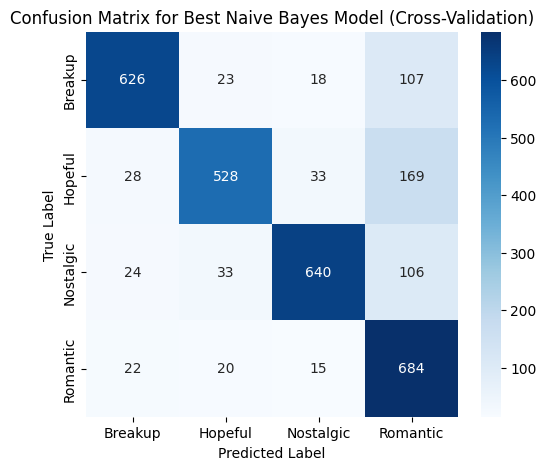

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_nb = confusion_matrix(y_test_nb, y_pred_nb_cv)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", xticklabels=best_model_nb.classes_, yticklabels=best_model_nb.classes_)
plt.title("Confusion Matrix for Best Naive Bayes Model (Cross-Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


This confusion matrix represents the performance of the best Naive Bayes model on the test set, after performing 5-fold cross-validation and hyperparameter tuning.

The confusion matrix provides a deeper look at how misclassifications occur, complementing the classification report.

The Breakup category shows 626 correct classifications, with 23 misclassified as Hopeful, 18 as Nostalgic, and 107 as Romantic. This confirms that the model performs well in identifying breakup songs with high confidence, though some overlap with romantic lyrics may exist.

For the Hopeful category, 528 songs were correctly classified, while 28 were misclassified as Breakup, 33 as Nostalgic, and 169 as Romantic. The confusion between Hopeful and Romantic may stem from thematic similarities, particularly where hope follows emotional pain or longing.

The Nostalgic category performs well overall, with 640 correct classifications. However, 24 were misclassified as Breakup, 33 as Hopeful, and 106 as Romantic. This suggests that some nostalgic lyrics may resemble themes found in romantic or breakup songs, contributing to classification confusion.

For the Romantic category, 684 songs were correctly classified. Misclassifications include 22 as Breakup, 20 as Hopeful, and 15 as Nostalgic. These errors may reflect the emotional overlap between romantic and other sentiment-heavy lyrics, especially breakup-related ones.

In [ ]:
# Print the best parameters and best cross-validation score.
print("Best parameters found:", grid_search_nb.best_params_)
print("Best cross-validation macro F1-score:", grid_search_nb.best_score_)

print("Classification Report (Single test split):")
print(classification_report(y_test_nb, y_pred_nb))

print("Classification Report (Cross Validation):")
print(classification_report(y_test_nb, y_pred_nb_cv))

Best parameters found: {'clf__alpha': 0.1, 'tfidf__max_features': None, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
Best cross-validation macro F1-score: 0.7558115833927708
Classification Report (Single test split):
              precision    recall  f1-score   support

     Breakup       0.72      0.65      0.68       774
     Hopeful       0.72      0.52      0.60       758
   Nostalgic       0.75      0.56      0.64       803
    Romantic       0.49      0.82      0.62       741

    accuracy                           0.63      3076
   macro avg       0.67      0.64      0.64      3076
weighted avg       0.67      0.63      0.64      3076

Classification Report (Cross Validation):
              precision    recall  f1-score   support

     Breakup       0.89      0.81      0.85       774
     Hopeful       0.87      0.70      0.78       758
   Nostalgic       0.91      0.80      0.85       803
    Romantic       0.64      0.92      0.76       741

    accuracy       

Comparing the single-test split model to the cross-validated model, we observe that accuracy increased from 0.63 to 0.81, and macro-average and weighted-average F1-scores both improved.

A single-test split can sometimes be misleading because of potential overestimation or underestimation of performance due to random variations in data partitioning.
The cross-validation approach provides a more stable estimate by averaging over multiple train-test divisions.
This reinforces that the initial test-split model may have overfitted to a particular train/test division, whereas the cross-validation model generalizes better across different subsets of the dataset.

Additionally, hyperparameter tuning played a role to help optimize performance across different partitions of the data, leading to better overall classification.
The best-found parameters included $\alpha = 0.1$ for Laplace smoothing, which helps the model handle rare words better, and TF-IDF max features = 5000, ensuring that only the most relevant words are used in classification.
The ngram range was set to (1,1), meaning unigrams (single words) were used instead of bigrams, likely because bigrams didn’t provide additional predictive value given the dataset's size.
Sublinear TF scaling was enabled, meaning the term frequency transformation dampened the impact of extremely frequent words, making rare but meaningful terms more influential in classification.

Below is the diagram that outlines the Naive Bayes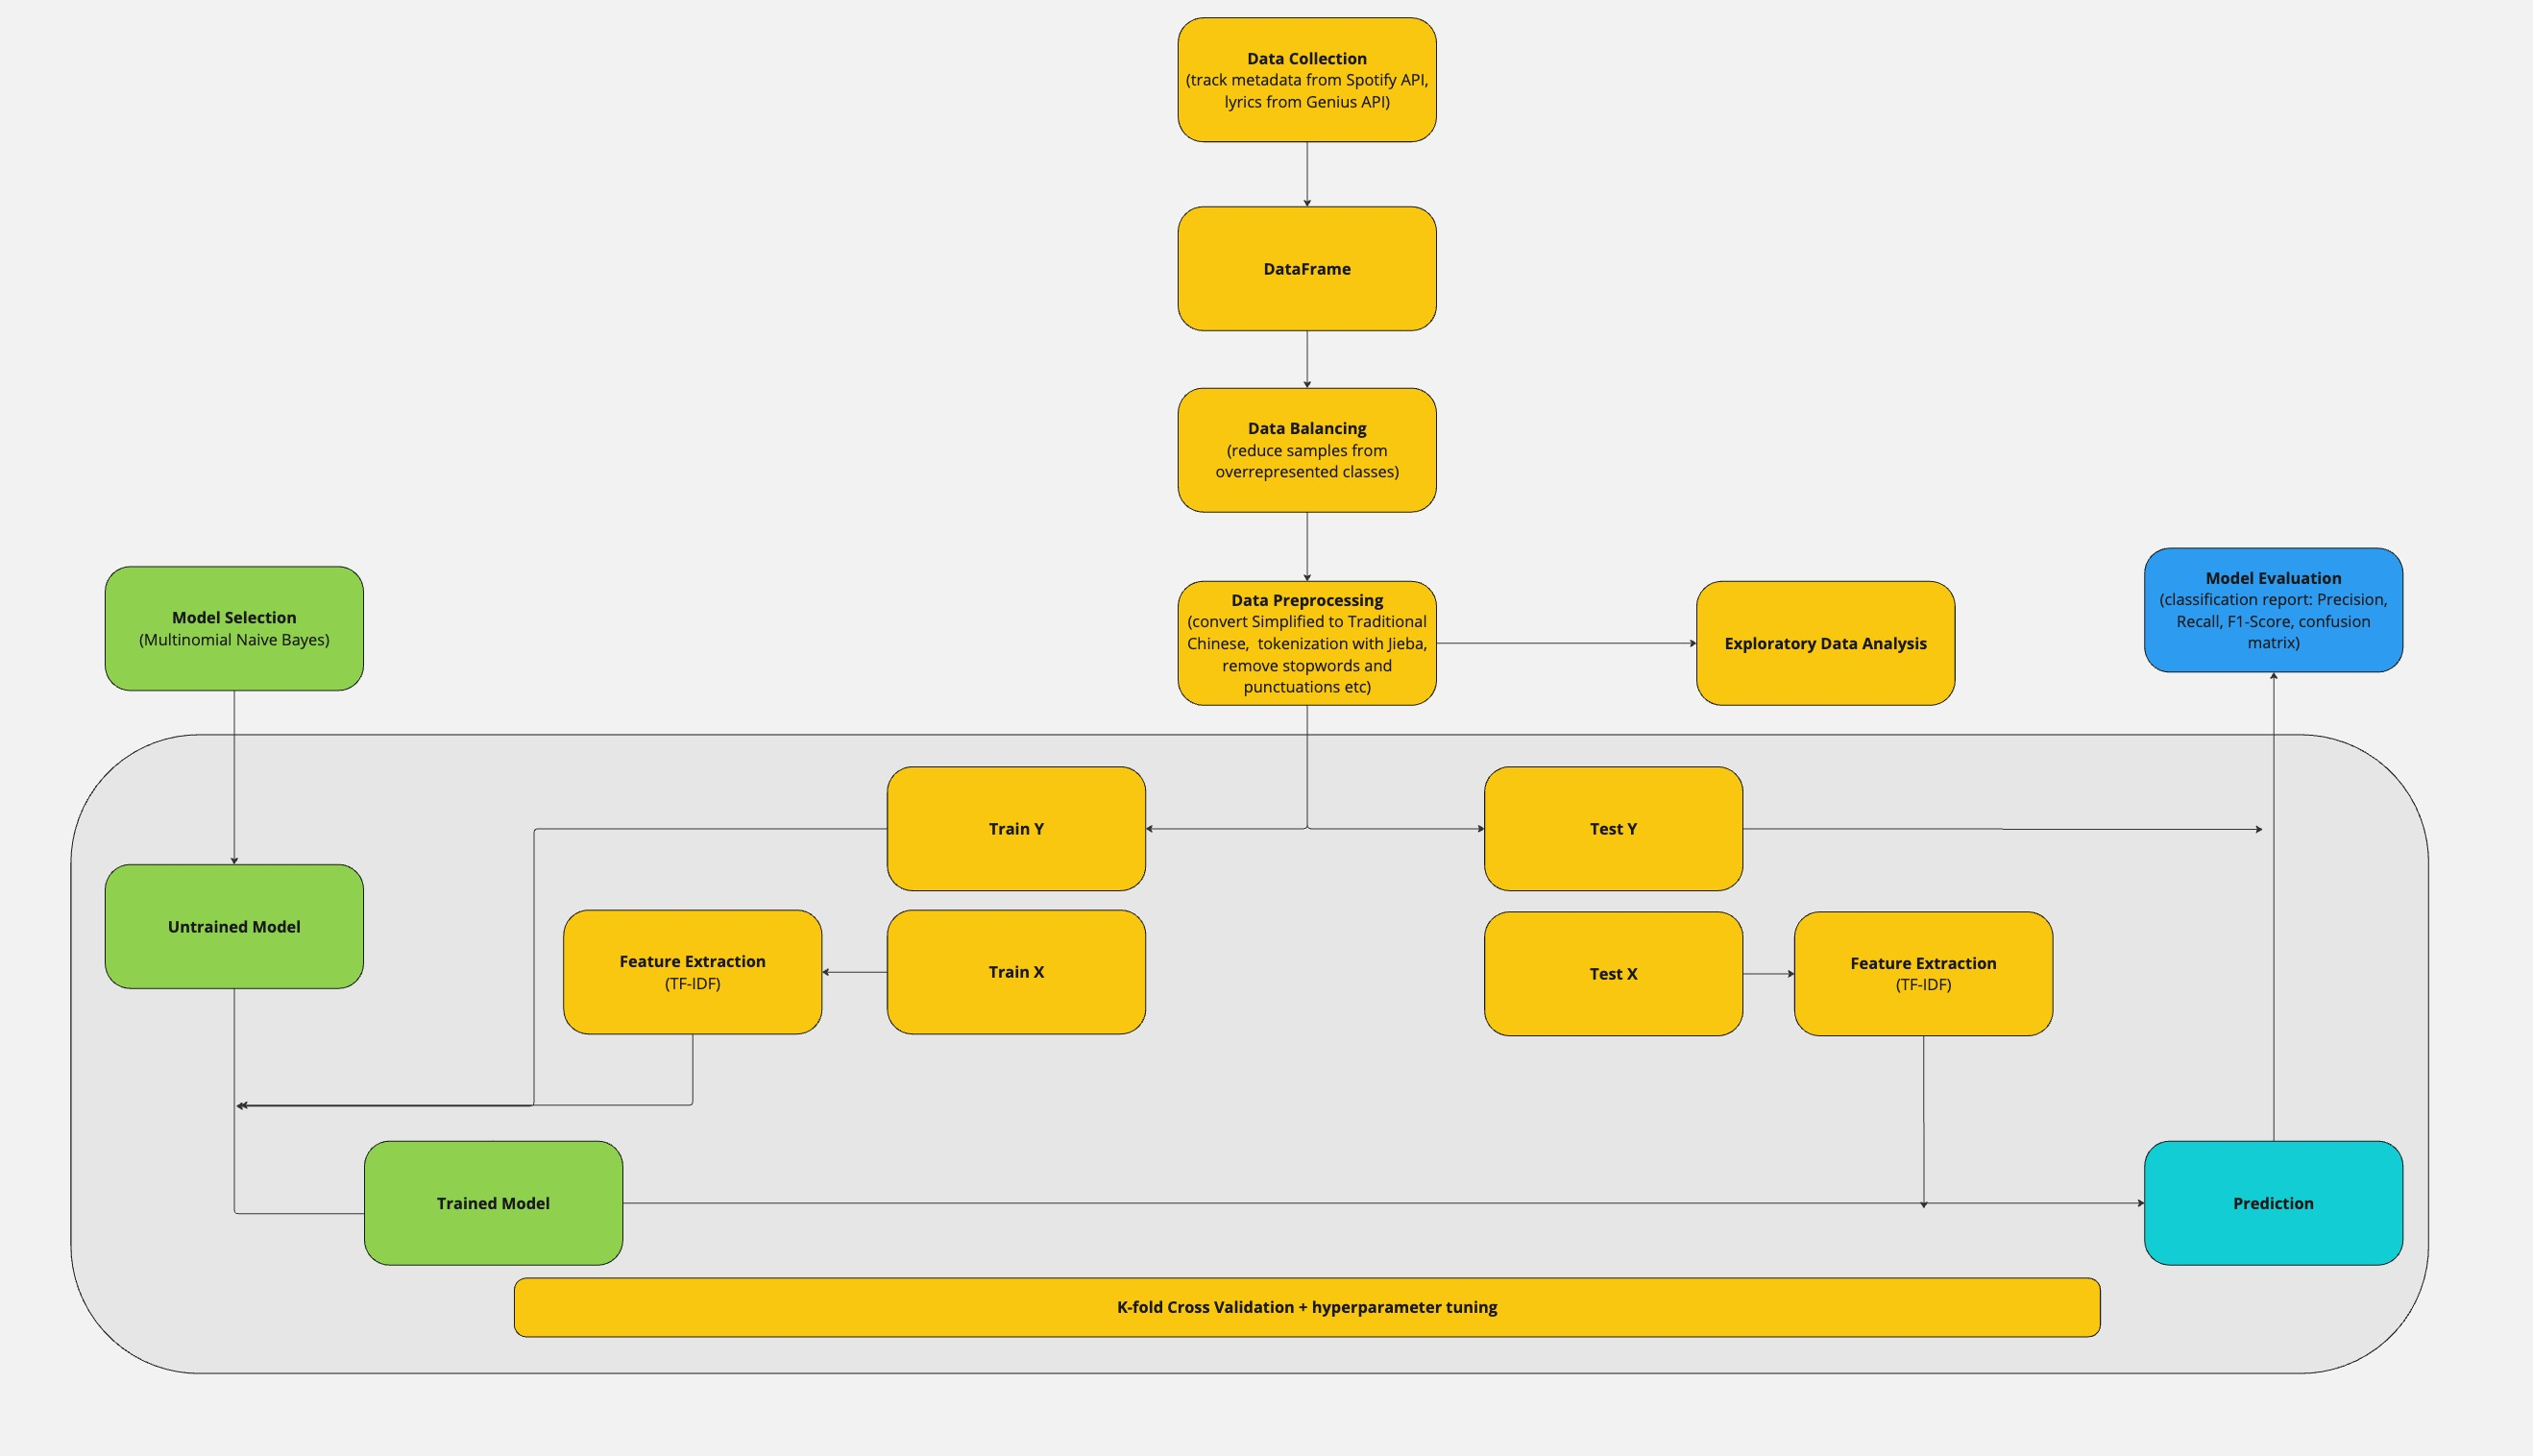 pipeline

### LSTM

I started with a Naive Bayes model as a baseline, since it's simple and fast to implement. While it was able to pick up on some basic word-frequency patterns, it didn’t account for word order or context. This was a limitation for lyrics, where the sequence of words often plays an important role in shaping meaning. For example, a line may begin with neutral or vague words but end with a decisive emotional turn. To better capture this type of structure, I used a Long Short-Term Memory (LSTM) model, which is specifically designed to work with sequential data.

LSTMs are a type of recurrent neural network (RNN) that process sequences step by step, maintaining a memory of previous inputs as they move through the text. Unlike standard RNNs, which can struggle to retain information over long sequences, LSTMs use gating mechanisms to decide which information to keep or discard at each time step. This allows them to capture longer-range dependencies and better understand how earlier parts of a sentence relate to what comes later. In a classification setting, this means the model can consider not just which words appear, but also how they are used together across the line.


An LSTM cell is designed to handle sequences where the order and long-term dependencies between elements matter (eg lines of song lyrics). The figure below shows the internal gates and pathways that help the LSTM decide what information to keep, what to forget, and what to output at each time step.

The black horizontal line running through the cell represents the cell state, which acts as a kind of memory conveyor belt. Information can flow along this path with only minor interactions, making it easier for the model to remember things over long sequences.

The first gate on the left is the forget gate, marked with a sigmoid (σ) followed by multiplication (×). This gate looks at the current input and the previous hidden state, and decides which parts of the cell state should be forgotten (i.e., set to zero). For example, in a lyric sequence, if a word no longer contributes to the theme, the forget gate helps remove its influence.

Next, the model computes a candidate update using a tanh activation, which proposes new information that might be added to the memory. This is combined with the input gate (another sigmoid), which controls how much of that new information is actually allowed through. Together, these two paths (input and candidate) determine how much new meaning enters the memory — say, when a key emotional word appears mid-lyric.

The updated memory is then passed through a tanh function and multiplied by the output gate (another sigmoid). This produces the new hidden state, which is the LSTM’s output for this time step. This hidden state is what gets passed to the next time step and can also be used directly for classification. In your case, this output would represent the evolving emotional or thematic state of a song line as it’s processed word by word.

By controlling the flow of information through these gates, LSTMs are able to keep relevant context across long lyric sequences — which is critical for understanding how a word like “不” (not) changes the sentiment of “愛” (love), or how repetition and buildup contribute to tone.

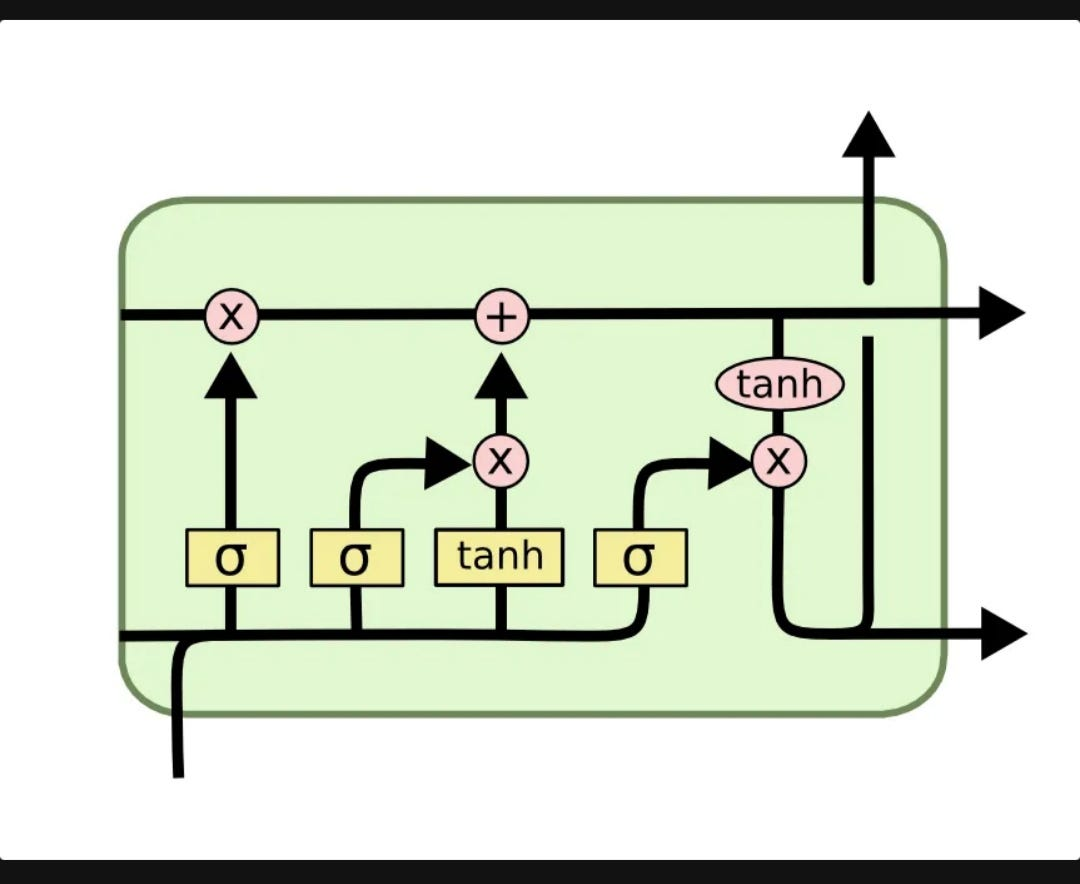


Mathematically, this is how LSTM works:
At each time step $t$, the LSTM receives three inputs:
- $x_t$: the input vector at the current time step (e.g., a word or token embedding),
- $h_{t-1}$: the hidden state from the previous time step,
- $c_{t-1}$: the cell state from the previous time step (the long-term memory).

The LSTM outputs two quantities:
- $h_t$: the updated hidden state,
- $c_t$: the updated cell state.



Firstly, the forget gate determines which parts of the previous cell state $c_{t-1}$ should be retained or discarded.

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

Where:
- $W_f$ is the weight matrix for the forget gate,
- $b_f$ is the bias vector,
- $\sigma(\cdot)$ is the sigmoid activation function, which outputs values in the range $(0, 1)$,
- $[\cdot, \cdot]$ denotes concatenation of the vectors $h_{t-1}$ and $x_t$.

Each element of $f_t$ determines how much of the corresponding element in $c_{t-1}$ should be kept. If $f_t^{(i)} \approx 1$, the memory is retained; if $f_t^{(i)} \approx 0$, it is forgotten.


The input gate controls which parts of the new information should be written to the memory cell. The candidate memory vector $\tilde{c}_t$ proposes new values to add.

The input gate is computed as:

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

The candidate memory is:

$$
\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
$$

Where:
- $W_i$ and $W_c$ are the weight matrices for the input gate and candidate memory, respectively,
- $b_i$ and $b_c$ are the bias vectors,
- $\tanh(\cdot)$ is the hyperbolic tangent activation function, which outputs values in $(-1, 1)$.


Then, The gate $i_t$ determines how much of the candidate $\tilde{c}_t$ will actually be added to the cell state.


The cell state is updated by combining the retained old memory (scaled by the forget gate) and the new candidate memory (scaled by the input gate):

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

Where:
- $\odot$ denotes element-wise multiplication.

This equation defines how the LSTM blends the old information with the new, enabling the model to preserve long-term dependencies while still integrating new input.


After that, the output gate determines what part of the cell state should be output as the new hidden state:

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

The new hidden state is computed as:

$$
h_t = o_t \odot \tanh(c_t)
$$

Where:
- $W_o$ and $b_o$ are the weight matrix and bias for the output gate.

The hidden state $h_t$ is the filtered and activated version of the current memory cell, which is used both as the output of the LSTM at this time step and as input for the next.



Thus, to summarize, the full set of equations governing the LSTM cell at time step $t$ is:

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \odot \tanh(c_t)
$$



As such, in this case, I applied an LSTM model by passing the padded sequences (where all lyric segments were zero-padded to a uniform length for batch training) through an embedding layer and then into an LSTM layer, which learned to capture patterns in word order and contextual flow. The model then produced a probability distribution across the four categories, enabling classification of each lyric segment. I chose to use an LSTM model because I wanted to go beyond word-level frequency and explore whether capturing local sequence information could improve classification performance. The model is well-suited to the structure of lyrics, where emotional meaning often unfolds within a line, and small changes in phrasing can shift the intended sentiment. However, LSTMs typically require larger datasets to generalize effectively. Although I used shingling to increase the dataset size, most lyric segments remained quite short (often just 2 to 5 tokens), which may have limited the model’s ability to learn more complex sequential patterns.

In the first step of preparing the target labels, I converted the categorical emotion labels (e.g., "Romantic", "Breakup", etc.) into integer values using `astype('category').cat.codes`. This assigns a unique integer to each category — for example, "Romantic" might become 0, "Breakup" might become 1, and so on. However, since the model's output layer uses a softmax activation to return a probability distribution over all possible classes, the true labels must also be represented in a compatible format — specifically, a one-hot encoded format. To achieve this, I applied `pandas.get_dummies()` to the integer labels. This produces a binary vector for each example, where only the index corresponding to the correct class is set to 1 and the rest are 0. For instance, if a label is class 2 in a 4-class problem, its one-hot encoding would be `[0, 0, 1, 0]`. This transformation is important because the model is trained using categorical cross-entropy loss, which compares the predicted probability distribution from the softmax layer to the true one-hot encoded label vector for each input. Without this step, the model would not be able to interpret or optimize against the label structure correctly.

In [ ]:
# One-hot encode labels using Pandas
df_balanced['label_id'] = df_balanced['label'].astype('category').cat.codes
lstm_label_names = df_balanced['label'].astype('category').cat.categories.tolist()
y_lstm = pd.get_dummies(df_balanced['label_id']).values

Then, I prepared the input text data by converting the space-separated lyrics into sequences of word indices using Keras’ `Tokenizer`. Each token (word or character, depending on segmentation) is mapped to a unique integer based on its frequency in the dataset. This numerical representation allows the model to process the lyrics as sequences of input vectors. Since LSTM models require inputs to be of consistent shape for efficient batch training, I padded each sequence to a fixed length of 20 tokens using `pad_sequences`. This ensures that all training samples have the same length, regardless of the original number of tokens in each lyric segment. Shorter sequences are padded with zeros at the end (`padding='post'`), and longer sequences are truncated. I chose a maximum length of 20 based on the observed distribution of token counts in the dataset — most segments were between 2 and 5 tokens, but a cap of 20 provides room for longer phrases without introducing excessive padding.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_lstm_text = df_balanced['processed']
lstm_tokenizer = Tokenizer()
lstm_tokenizer.fit_on_texts(X_lstm_text)

X_lstm_seq = lstm_tokenizer.texts_to_sequences(X_lstm_text)
lstm_maxlen = 20  # Based on your token histogram
X_lstm_pad = pad_sequences(X_lstm_seq, padding='post', maxlen=lstm_maxlen)

After that, I divided the dataset into training and testing sets using an 80/20 split (same as Naive Bayes model). This separation allows the model to be evaluated on unseen data after training, providing a more realistic measure of generalization performance. I set the `random_state` to 66 for reproducibility.

In [ ]:
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
    X_lstm_pad, y_lstm, test_size=0.2, random_state=42
)

The table above summarizes the architecture of the LSTM model as defined using Keras' Sequential API. It lists each layer in the order they are applied, along with their type, output shape, and number of trainable parameters. The first layer, `embedding_2`, corresponds to the Embedding layer, which converts integer word indices into dense 128-dimensional vectors. This layer has not yet been fully built because the model has not received any input data yet; the input shape will be inferred either when training starts or if the model is manually built with a specified input shape. The second layer, `lstm_2`, is the LSTM layer with 64 units, responsible for processing the embedded sequences and capturing temporal dependencies and structural patterns in the lyrics. This is followed by two dense (fully connected) layers: `dense_4`, which applies a ReLU activation to introduce non-linearity and allow for more complex interactions between learned features, and `dense_5`, which is the output layer with a softmax activation that produces a probability distribution over the emotion categories. The table currently shows all parameter counts as zero because the model has not yet been compiled or run on any data, so the internal weight matrices have not been initialized. Once the model is compiled and receives input data, the full shapes and parameter values will be populated. Monitoring the number of trainable parameters provides us with insight into the model's capacity to learn from data, and helps assess the potential risk of overfitting, especially when working with a moderately sized dataset like this one, where each lyric segment remains relatively short and information per sample is limited.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_vocab_size = len(lstm_tokenizer.word_index) + 1  # +1 for padding token

lstm_model = Sequential([
    Embedding(input_dim=lstm_vocab_size, output_dim=128, input_length=lstm_maxlen),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(y_lstm.shape[1], activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

To ensure the model remains generalizable and avoids overfitting, I incorporated an early stopping mechanism into the training process. Early stopping monitors the validation loss during training and automatically halts the process once the loss stops improving for a predefined number of epochs. This prevents the model from continuing to train after it has already reached its optimal performance on unseen data, which can otherwise lead to memorization of training-specific patterns that do not generalize well. Additionally, early stopping restores the model weights from the epoch with the best validation performance, ensuring that the final model used for evaluation reflects the most effective parameter configuration. Beyond regularization, this approach also helps identify the ideal number of training epochs required, removing the need to arbitrarily fix this value in advance. This is particularly useful in the context of Chinese lyrics classification, where each input segment is relatively short and the model may converge quickly. I chose a patience value of 2 to strike a balance between sensitivity and stability,allowing the model one or two minor fluctuations in validation loss without terminating prematurely, while still halting the training early enough to avoid overfitting.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

lstm_early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Model training
lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[lstm_early_stop]
)

Epoch 1/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6956 - loss: 0.7631 - val_accuracy: 0.6872 - val_loss: 0.7999
Epoch 2/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8002 - loss: 0.4974 - val_accuracy: 0.7254 - val_loss: 0.7453
Epoch 3/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8482 - loss: 0.3699 - val_accuracy: 0.7474 - val_loss: 0.7120
Epoch 4/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8693 - loss: 0.3091 - val_accuracy: 0.7620 - val_loss: 0.6935
Epoch 5/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8739 - loss: 0.2919 - val_accuracy: 0.7734 - val_loss: 0.8141
Epoch 6/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8825 - loss: 0.2678 - val_accuracy: 0.7782 - val_loss: 0.7558


Based on the classification report, the test set yielded an overall accuracy of 76%, with a macro-average F1 score of 0.77. These results suggest that the model performs reasonably well across all four emotion categories, though with some variation in class-specific performance. The "Breakup" and "Nostalgic" categories achieved the highest F1 scores (0.82 for both), indicating a good balance between precision and recall. "Hopeful" also performed well in terms of precision (0.80), but had a lower recall (0.63), suggesting that while the model was confident when predicting this class, it failed to identify a number of true "Hopeful" samples. Conversely, "Romantic" showed the opposite trend: it achieved a high recall of 0.90, but a low precision of 0.60, meaning that many samples were classified as "Romantic" even when they were not. This tradeoff is often observed in imbalanced or semantically overlapping categories and highlights a common challenge in emotion classification tasks, particularly when categories may share thematic or linguistic similarities.

In [ ]:
y_lstm_pred_probs = lstm_model.predict(X_lstm_test)
y_lstm_pred = np.argmax(y_lstm_pred_probs, axis=1)
y_lstm_true = np.argmax(y_lstm_test, axis=1)

print(classification_report(y_lstm_true, y_lstm_pred, target_names=lstm_label_names))

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

     Breakup       0.87      0.77      0.82       774
     Hopeful       0.80      0.63      0.70       758
   Nostalgic       0.89      0.76      0.82       803
    Romantic       0.60      0.90      0.72       741

    accuracy                           0.76      3076
   macro avg       0.79      0.77      0.77      3076
weighted avg       0.79      0.76      0.77      3076



The confusion matrix offers a more detailed view of the model’s prediction patterns across the four emotion categories. Diagonal cells represent correct predictions, while off-diagonal cells indicate misclassifications. As shown, most "Breakup" and "Nostalgic" samples were correctly classified (598 and 613, respectively), which aligns with their high F1 scores. However, the model struggled more with "Hopeful" and "Romantic" distinctions. Specifically, a significant number of "Hopeful" samples (211) were misclassified as "Romantic", which supports the earlier observation of low recall (0.63) in the "Hopeful" class. Similarly, 114 "Breakup" samples were also misclassified as "Romantic," indicating that the model may be overly biased toward predicting "Romantic" due to the class’s emotional proximity to others or potential linguistic overlap in Chinese lyrics.


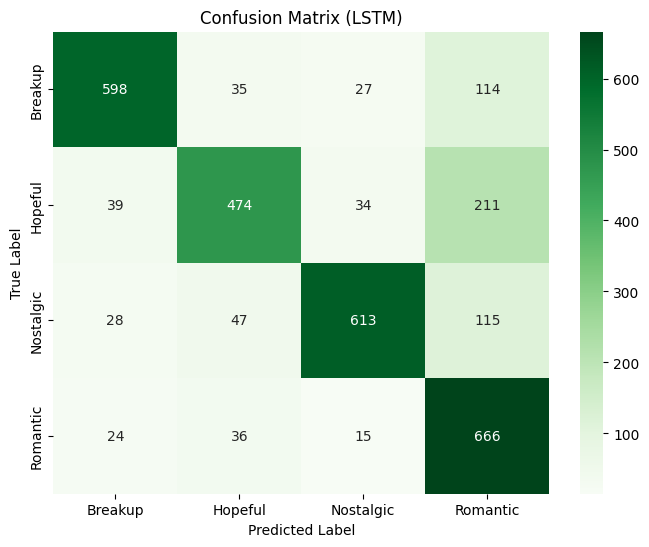

In [ ]:
import seaborn as sns
lstm_cm = confusion_matrix(y_lstm_true, y_lstm_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=lstm_label_names, yticklabels=lstm_label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (LSTM)')
plt.show()

### Bidirectional LSTM (BiLSTM) + Attention Model

In the previous section, I implemented a standard unidirectional LSTM model, which processes input sequences sequentially from left to right, building a hidden representation at each time step based only on the current token and all preceding tokens.this approach has a key limitation: it can only incorporate context that precedes a given token, ignoring any information that might follow. For instance, if the true sentiment or meaning of a lyric becomes clear only after encountering later words, a unidirectional model would miss that signal during its forward pass. In the context of Chinese lyrics, where sentences often feature flexible word orders and important emotional cues may appear toward the end of a phrase, this limitation could significantly impact classification accuracy.


To address this limitation, I extend the model to a Bidirectional LSTM (BiLSTM), which processes each sequence in both forward and backward directions and concatenates the two hidden states. This architecture enables the model to incorporate both past and future context when making predictions at each token position, This is critical for interpreting Chinese lyrics, as they often rely on poetic structures that do not follow strict syntactic order. For instance, Chinese lyricism frequently employs inversion, where the emotional climax is placed at the end of a phrase. In a line like “離別時我們微笑” (“At parting, we smile”), the sentiment of quiet acceptance is not fully apparent until the word “微笑” (“smile”) appears, potentially leading a unidirectional model to misclassify the line before reaching that emotional pivot. Similarly, parallelism is used to build emotional resonance by repeating syntactic structures with slight variation — such as “我想你 / 我等你 / 我守你” (“I miss you / I wait for you / I guard you”), where each clause incrementally deepens the tone. A model that only sees one side of the sequence might fail to detect this buildup. Finally, non-linear phrasing occurs when emotional cues are scattered across the line or deferred until the end. For example, in the line “夢想在破碎之後依然閃爍” (“Dreams after shattering still shimmer”), the key emotional message — resilience — is only revealed after the initial despair.


I expect that this richer contextual encoding will improve the model’s ability to distinguish between nuanced emotional categories, particularly those like "Hopeful" and "Nostalgic," which were often misclassified as "Romantic" in the baseline model. In the unidirectional LSTM, short lyric segments containing generic affectionate or poetic language were likely interpreted as "Romantic" due to the absence of future context. By incorporating both preceding and following tokens, the Bidirectional LSTM can better disambiguate these cases — for example, recognizing when a line begins with affection but ends in uncertainty ("Hopeful") or reflection ("Nostalgic"). This should help improve the tendency to overpredict the "Romantic" label and yield a more balanced classification.

To help visualize how a BiLSTM functions, consider the following diagram: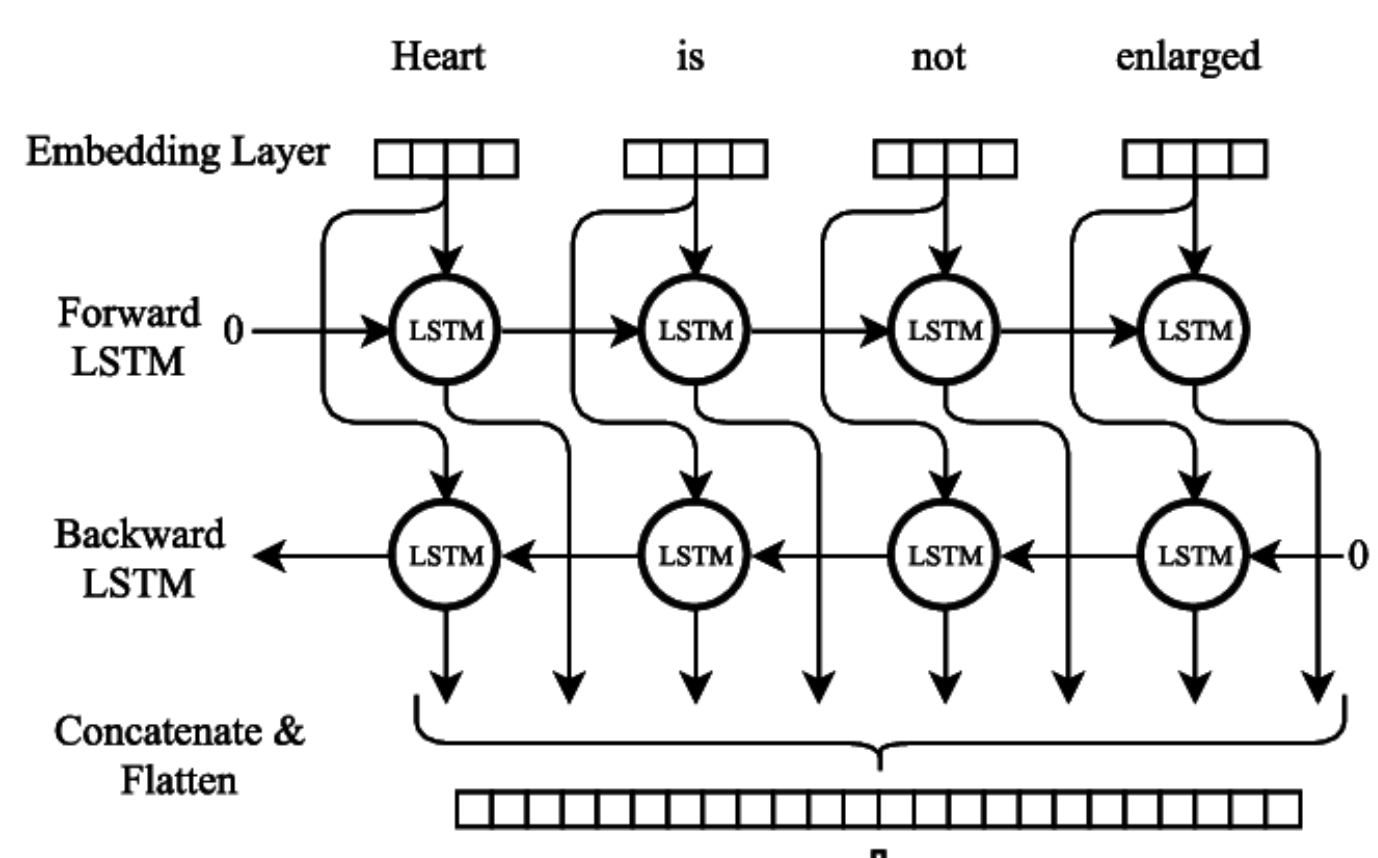

In the phrase “Heart is not enlarged,” the meaning hinges on how words relate to one another across the entire sentence. Unlike a standard LSTM that reads input in only one direction (typically left to right), a BiLSTM processes the sequence in both forward and backward directions, allowing it to leverage full context for each word — both what came before and what follows.

The process begins with the embedding layer, which transforms each word into a dense vector representation. These embeddings encode semantic properties of the words. For example, “Heart” and “enlarged” may appear in medical texts and have related embeddings, while “not” serves as a modifier in many contexts.

Next, the input embeddings are fed into two separate LSTM layers. The forward LSTM reads the sentence from left to right:
“Heart → is → not → enlarged.”
At each step, the forward LSTM processes the current word along with its previous hidden state, gradually building up an understanding based on past context. For example, by the time it reaches “enlarged,” the model already has internal representations of “Heart is not,” which informs how it interprets the final word.

Simultaneously, the backward LSTM reads the sentence in reverse:
“enlarged → not → is → Heart.”
This allows it to capture future context at each point in the sentence. When the backward LSTM is processing “Heart,” it already knows the rest of the sentence (that it's not enlarged) and can adjust its interpretation accordingly.

At every word position, the hidden states from both directions are concatenated, combining the insights gained from past and future context. This results in a richer, bidirectional representation of each word. For instance, the word “not” is crucial here, because it negates “enlarged,” and without both directions of context, a model might miss its scope. By seeing what comes before (“is”) and what comes after (“enlarged”), the BiLSTM can correctly model the negation and understand the overall meaning.

Finally, the sequence of combined vectors can be used for downstream tasks, in our case, classifying the emotion or theme of a song lyric. These final representations capture not just the meaning of individual words, but also how each word relates to the overall sentence, which is why BiLSTM is especially useful for understanding complex and structured language.

In terms of the math, how a bidirectional LSTM works is that it consists of two LSTM layers working in parallel: one that processes the sequence in the forward direction (from $t = 1$ to $T$), and another in the reverse direction (from $t = T$ to $1$). This allows the model to learn dependencies and context from both the past and future of a sequence.

At each time step $t$, a standard (unidirectional) LSTM only produces a hidden state $\vec{h}_t$ based on the current input $x_t$ and the previous hidden state $\vec{h}_{t-1}$. In contrast, a Bidirectional LSTM also considers a backward hidden state $\overleftarrow{h}_t$, computed by traversing the input in reverse.

The final output at each time step is the concatenation of the forward and backward hidden states:

$$
h_t = [\vec{h}_t; \overleftarrow{h}_t]
$$

where:
- $\vec{h}_t$ is the hidden state from the forward LSTM (processing left to right),
- $\overleftarrow{h}_t$ is the hidden state from the backward LSTM (processing right to left).

Thus, the combined output $h_t$ at each time step has double the dimensionality compared to a single LSTM direction. In matrix form, the full sequence of outputs becomes:

$$
H = [h_1, h_2, \dots, h_T] \in \mathbb{R}^{T \times 2d}
$$

where $d$ is the hidden dimension size of one LSTM direction.


This bidirectional processing is particularly well-suited for Chinese lyric classification, where the emotional tone of a line may depend on characters that appear early or late in the sequence. Since Chinese does not use spaces to separate words, and poetic lyrics often invert normal word order or rely on symmetric phrasing, it’s not always clear where key information is located within a line. A standard LSTM only considers past context when making predictions, but the BiLSTM has access to both sides of the sentence simultaneously, enabling it to model global dependencies more effectively. For example, in a line expressing longing, the final character might reverse the emotional direction of the entire phrase — and a unidirectional model might miss that. By combining the two perspectives, the BiLSTM can learn more nuanced temporal features that are especially important for subtle emotion recognition.

Additionally, while a BiLSTM improves over a unidirectional LSTM by incorporating context from both directions, it still treats each hidden state equally when producing the final output. That is, after processing the input sequence, the model averages or flattens all token representations regardless of their relative importance. In tasks like Chinese lyric classification, where a few emotionally significant words often determine the overall sentiment of a line, this uniform weighting can dilute critical information. To address this, I augment the BiLSTM with an attention mechanism that dynamically learns which tokens should contribute more to the final decision.

The core idea of an attention model is to assign learned importance scores to each token in a sequence. Instead of treating all positions equally, attention enables the model to focus on the words most relevant to the classification task — for example, highlighting the final word “微笑” (“smile”) in “離別時我們微笑” (“At parting, we smile”), or the contrast between “破碎” (“shattered”) and “閃爍” (“shimmer”) in “夢想在破碎之後依然閃爍” (“Dreams after shattering still shimmer”). These cues are subtle and often emotionally weighted, and attention allows the model to learn this weighting automatically, rather than relying on fixed pooling or compression.

This mechanism is illustrated in the diagram above.

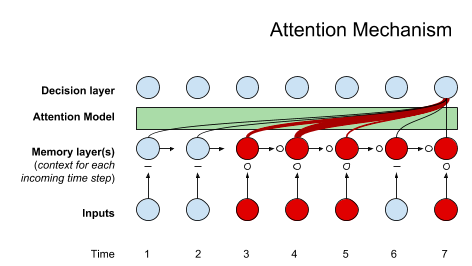

At the bottom, each input token is passed through a BiLSTM, producing a sequence of hidden states (the memory layer). These hidden states are then passed to the attention module, which computes a score for each time step based on its relevance to the overall classification task. The thicker arrows in the diagram represent higher attention weights, showing how the model might place more emphasis on certain tokens (e.g., time step 3 or 7) when constructing the final representation. The attention-weighted hidden states are aggregated into a context vector, which is then used by the decision layer to make the final prediction. This allows the model to retain information from the entire sequence but prioritize tokens that carry the most emotional or thematic weight.

Mathematically, given a BiLSTM output sequence:

$$
H = [h_1, h_2, \ldots, h_T], \quad h_t \in \mathbb{R}^{2d}
$$

where $h_t$ is the concatenation of the forward and backward hidden states at time step $t$, the attention mechanism first computes an unnormalized attention score for each time step:

$$
e_t = \tanh(W_a h_t + b_a)
$$

where $W_a \in \mathbb{R}^{k \times 2d}$ and $b_a \in \mathbb{R}^{k}$ are trainable parameters, and $e_t \in \mathbb{R}^{1}$ is a scalar relevance score.

These scores are then normalized using a softmax function to produce the attention weights:

$$
\alpha_t = \frac{\exp(e_t)}{\sum_{i=1}^{T} \exp(e_i)}
$$

The context vector is then calculated as the weighted sum of hidden states:

$$
c = \sum_{t=1}^{T} \alpha_t h_t
$$

This context vector $c \in \mathbb{R}^{2d}$ summarizes the most relevant parts of the sequence and is passed into the output layer for classification.


In practice, this mechanism enables the model to capture subtle emotional cues in Chinese lyrics that might otherwise be missed. For instance, in a line like “我沒忘記，只是學會了沉默” (“I didn’t forget, I just learned to be silent”), the attention model can prioritize “沉默” (“silence”) over earlier tokens, recognizing that the emotional tone hinges on the contrast introduced at the end. Especially in cases where categories such as “Hopeful” and “Nostalgic” overlap semantically, attention helps the model learn more discriminative features by anchoring its decision on key sentiment-bearing words. I expect this will further reduce confusion between closely related categories and help correct the overprediction of generic or dominant labels like “Romantic,” yielding a more nuanced and emotionally precise classification.

#### execution

These two code cells define a custom attention layer and sets key hyperparameters for the BiLSTM model. The bilstm_attention_layer function computes soft attention weights over the LSTM output at each time step using a learnable `Dense` layer with a `tanh` activation, followed by softmax normalization (wrapped safely in a `Lambda` layer for Keras compatibility). These weights are then applied to the BiLSTM outputs using elementwise multiplication, and a context vector is computed via `GlobalAveragePooling1D`. This layer allows the model to focus on the most relevant words in the input sequence, which is particularly useful in lyric classification where emotional cues may be concentrated in only a few tokens. The choice of 128-dimensional embeddings and 64 hidden units for the LSTM was made to balance expressiveness with runtime efficiency, and the dropout values (0.3 for regular dropout, 0.2 for recurrent dropout) were selected to prevent overfitting without overly impairing learning.

In [ ]:
from tensorflow.keras.layers import Dense, Multiply, Lambda

def bilstm_attention_layer(inputs):
    # inputs: [batch_size, seq_len, hidden_dim*2]

    # 1. Learn attention scores
    attention_scores = Dense(1, activation='tanh')(inputs)  # shape: [batch_size, seq_len, 1]

    # 2. Normalize scores using softmax across time steps
    attention_weights = Lambda(lambda x: tf.nn.softmax(x, axis=1))(attention_scores)  # shape: [batch_size, seq_len, 1]

    # 3. Apply attention weights to BiLSTM outputs
    weighted_inputs = Multiply()([inputs, attention_weights])  # shape: [batch_size, seq_len, hidden_dim*2]

    # 4. Sum across the sequence to get a fixed-size context vector
    context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted_inputs)  # shape: [batch_size, hidden_dim*2]

    return context_vector

In [ ]:
# Model Parameters
bilstm_vocab_size = len(lstm_tokenizer.word_index) + 1
embedding_dim = 128
lstm_units = 64
dense_units = 32
dropout_rate = 0.3
recurrent_dropout = 0.2
num_classes = y_lstm.shape[1]
lstm_maxlen = X_lstm_train.shape[1]

This cell constructs the full BiLSTM + Attention model using the Keras functional API. The input layer receives padded lyric sequences of fixed length (lstm_maxlen). These are passed through an embedding layer, followed by a Bidirectional LSTM with dropout. The use of a bidirectional architecture allows the model to capture both preceding and succeeding context, which is essential for handling flexible syntactic structures common in Chinese lyrics. After the LSTM, the attention layer is applied to dynamically reweight token representations based on their relevance to the classification task. The output from the attention mechanism is passed through a fully connected layer with ReLU activation and dropout regularization, then finally to a softmax layer for multi-class classification. The model uses categorical crossentropy loss and the Adam optimizer, both standard and effective choices for this kind of task.

In [ ]:
bilstm_input = Input(shape=(lstm_maxlen,))

x = Embedding(input_dim=bilstm_vocab_size,
              output_dim=embedding_dim,
              input_length=lstm_maxlen)(bilstm_input)

x = Bidirectional(LSTM(lstm_units, dropout=dropout_rate,
                       recurrent_dropout=recurrent_dropout,
                       return_sequences=True))(x)

x = bilstm_attention_layer(x)

x = Dense(dense_units, activation='relu')(x)
x = Dropout(dropout_rate)(x)

bilstm_output = Dense(num_classes, activation='softmax')(x)

bilstm_model = Model(inputs=bilstm_input, outputs=bilstm_output)

This summary displays the architecture and parameter count of the model. It confirms that the attention mechanism is functioning as intended: the BiLSTM produces outputs of shape `(None, 20, 128)`, and attention reduces this to a fixed-size vector of `(None, 128)` through a weighted pooling operation. The model has just over 1.2 million trainable parameters, which is a manageable size for a medium-sized dataset, suggesting that it is expressive but not excessively prone to overfitting. Viewing the shape transitions here is also useful to verify that layer dimensions are compatible, particularly since attention-based models often break if dimensions are not carefully managed.


In [ ]:
bilstm_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

bilstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 20, 128)   │  1,124,864 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 20, 128)   │     98,816 │ embedding_4[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 20, 1)     │        129 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 20, 1)     │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 20, 128)   │          0 │ bidirectional_3[… │
│ (Multiply)          │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      4,128 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │        132 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,228,069 (4.68 MB)

 Trainable params: 1,228,069 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

This cell trains the BiLSTM + Attention model with early stopping. The model is trained for up to 20 epochs with a batch size of 32 and a 10% validation split. Early stopping monitors the validation loss and restores the best weights if no improvement is seen after 2 epochs, which helps prevent overfitting and unnecessary computation. The batch size and patience values were selected based on common best practices and early experimental tuning. The progress bars during training provide real-time feedback, helping to track model convergence visually.

In [ ]:
bilstm_early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [ ]:
bilstm_history = bilstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[bilstm_early_stop]
)

Epoch 1/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.2767 - loss: 1.3765 - val_accuracy: 0.4760 - val_loss: 1.1707
Epoch 2/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.5711 - loss: 0.9986 - val_accuracy: 0.6694 - val_loss: 0.8677
Epoch 3/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.7893 - loss: 0.5801 - val_accuracy: 0.7368 - val_loss: 0.7517
Epoch 4/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8448 - loss: 0.3929 - val_accuracy: 0.7652 - val_loss: 0.7356
Epoch 5/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.8650 - loss: 0.3391 - val_accuracy: 0.7620 - val_loss: 0.7043
Epoch 6/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.8727 - loss: 0.2968 - val_accuracy: 0.7750 - val_loss: 0.8062
Epoch 7/20
347/347 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.8877 - loss: 0.2709 - val_accuracy: 0.7734 - val_loss: 0.8072


In [ ]:
y_bilstm_pred_probs = bilstm_model.predict(X_lstm_test)
y_bilstm_pred = np.argmax(y_bilstm_pred_probs, axis=1)
y_bilstm_true = np.argmax(y_lstm_test, axis=1)

print("BiLSTM + Attention Results")
print(classification_report(y_bilstm_true, y_bilstm_pred, target_names=lstm_label_names))

97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
BiLSTM + Attention Results
              precision    recall  f1-score   support

     Breakup       0.87      0.79      0.83       774
     Hopeful       0.59      0.84      0.69       758
   Nostalgic       0.86      0.78      0.81       803
    Romantic       0.81      0.63      0.71       741

    accuracy                           0.76      3076
   macro avg       0.78      0.76      0.76      3076
weighted avg       0.78      0.76      0.76      3076



### BERT


After experimenting with Naive Bayes, LSTM, and Bidirectional LSTM models, I found that each had its own strengths and limitations. While LSTMs allowed the model to take word order into account, and BiLSTMs added the ability to look at context from both directions, both models still relied on learning everything from scratch using my dataset. They had no built-in knowledge of language, which meant they sometimes struggled to handle metaphors, uncommon phrases, or emotionally complex lyrics — especially when training data was limited or fragmented.

To address this, I lastly turned to BERT (Bidirectional Encoder Representations from Transformers), a large-scale pretrained language model developed by Google. Unlike LSTMs, which process text sequentially and rely on learned memory, BERT has been trained on massive amounts of text data using masked language modeling (MLM) and next sentence prediction (NSP). These objectives help BERT learn deep contextual relationships — not just between adjacent words, but across entire sentences. Because BERT processes text bidirectionally from the start, it captures richer semantic meaning, which I hoped would lead to better performance on Chinese lyrics, where the emotional weight of a line often depends on subtle phrasing, symbolism, or non-literal language.

For example, a phrase like “紅了櫻桃” (“the cherries turn red”) may seem simple on the surface, but in many Chinese songs, it acts as a metaphor for fleeting youth or the passage of time. A model like Naive Bayes, which treats “紅” (“red”) and “櫻桃” (“cherry”) as isolated tokens, would miss this deeper meaning. Even LSTMs may struggle if such metaphorical constructions are rare in the training set. In contrast, BERT’s pretrained embeddings already encode knowledge of metaphorical, cultural, and syntactic patterns, making it more capable of interpreting such nuanced lyrics.

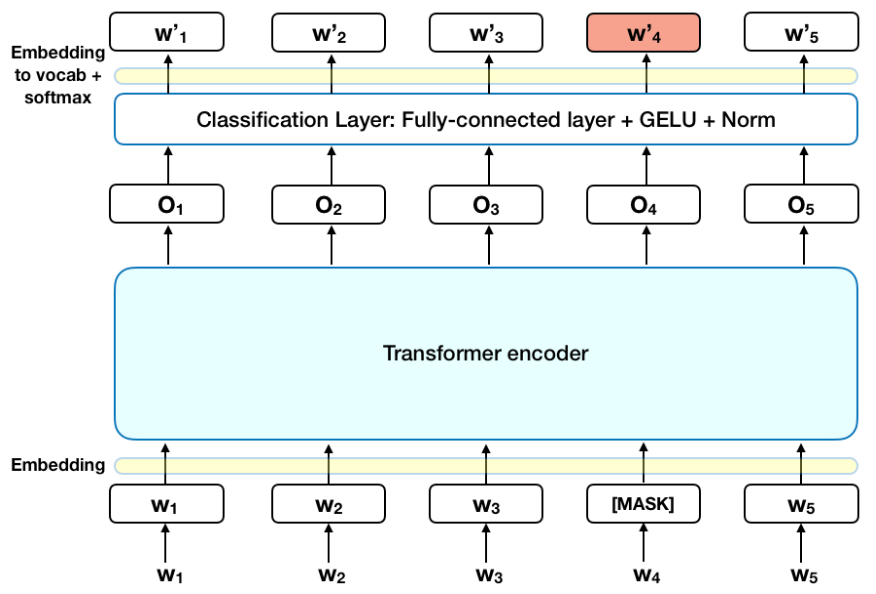

BERT starts by breaking down the input sentence into a series of tokens—for example, W₁, W₂, W₃, [MASK], W₅. Each of these tokens is converted into a vector through an embedding layer, which turns them into a format the model can understand.

These vectors are then fed into a stack of transformer encoder layers. Instead of processing tokens one at a time, the transformer looks at all of them at once using a mechanism called self-attention. This allows BERT to understand how each word relates to the others, both before and after it, which helps it build a better understanding of the overall meaning.

Once processed, each token is assigned a context-aware output vector—like O₁ to O₅. The vector for the masked word (in this case, O₄) captures information from the entire sentence. This helps the model make an educated guess about which word should go in the masked position.

These output vectors are then passed through a small classifier made up of a dense layer, a GELU activation function (which adds some non-linearity), and layer normalization. This helps fine-tune the representations before making a prediction.

To figure out what the masked word should be, the model maps the final output back to the vocabulary space using the same embedding weights and applies a softmax function. This gives a probability distribution over all possible words, and the model selects the most likely one.

During training, BERT uses cross-entropy loss to compare its prediction with the actual masked word. The goal is to reduce this difference, so over time the model gets better at understanding the context of sentences and predicting missing words.


Below is a breakdown of how it processes a sentence mathematically.

**Token and Positional Embedding**

Firstly, each token (word or character) is first converted into an embedding vector. However, because Transformers don't have inherent knowledge of word order, BERT adds positional encoding to each embedding.

The positional encoding is defined using sine and cosine functions:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}} \right), \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}} \right)
$$

where:
- $pos$ is the position index in the sequence,
- $i$ is the dimension index,
- $d$ is the embedding dimension (e.g., 768 for BERT-base).

The final embedding for each token is:

$$
x_i = \text{TokenEmbedding}(t_i) + \text{PositionalEncoding}(i)
$$

where TokenEmbeddings tell the model what the word is (e.g., "我" = "I", "愛" = "love"), and PositionalEncodings tell the model where the word is (1st word, 2nd word, etc.).


**Self-Attention Mechanism**

The self-attention mechanism is the core operation that allows BERT to model relationships between words across the entire input sequence. Instead of treating words independently or only looking at immediate neighbors, self-attention enables each token to attend to (i.e., focus on) all other tokens in the sentence and adjust its own representation based on the broader context.

For each token embedding $x_i$, we project it into three vectors using learned weight matrices:

- Query: $Q = x_i W^Q$ — represents what the token is "looking for" in other tokens,
- Key: $K = x_i W^K$ — represents what each token "offers" to others,
- Value: $V = x_i W^V$ — contains the actual content that should be aggregated if the token is relevant.

These projections transform the input into a new space where similarity (dot product between Query and Key) can be meaningfully measured.

The attention weights between tokens are computed as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V
$$

where:
- $Q \in \mathbb{R}^{n \times d_k}$ is the matrix of queries,
- $K \in \mathbb{R}^{n \times d_k}$ is the matrix of keys,
- $V \in \mathbb{R}^{n \times d_v}$ is the matrix of values,
- $n$ is the sequence length (number of tokens),
- $d_k$ is the dimension of the key vectors.

First, we compute the dot product $QK^\top$ to obtain raw attention scores between each query and all keys. These scores are scaled by $\sqrt{d_k}$ to prevent overly large values, which could destabilize softmax. The softmax then normalizes the scores into a probability distribution for each query — assigning higher probabilities to more relevant tokens.

Finally, each query's output is computed as a weighted sum of all values, using these attention weights. This means each token’s new embedding is an aggregation of information from all tokens it deems important, not just nearby ones.

This mechanism enables BERT to dynamically focus on different parts of a sentence when interpreting a token. For example, in a sentence like "還是月下老人他傻傻分不清" ("Or is it that the Matchmaker God foolishly can't tell the difference?"), the pronoun "他" ("he") can correctly attend more to "月下老人" ("the Matchmaker God") rather than treating "老人" ("old man") separately — because self-attention considers the full sequence at once.


**Multi-Head Attention**

In the self-attention mechanism described earlier, a single set of $Q$, $K$, and $V$ projections is used to compute attention scores and aggregate information. However, using only one attention head can limit the model’s ability to capture diverse types of relationships between words.

To address this, BERT uses multi-head attention, where the model computes multiple sets of attention in parallel, each with its own learned projections.

The multi-head attention operation is defined as:

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O
$$

where each attention head is computed independently as:

$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V)
$$

Here:
- $W_i^Q$, $W_i^K$, $W_i^V$ are learned weight matrices for the $i$-th head,
- $h$ is the number of heads (e.g., 12 heads for BERT-base),
- $W^O$ is the output projection matrix applied after concatenating all heads.

Each head operates in its own learned subspace, meaning different heads can specialize in capturing different types of relationships. Some heads may focus on syntactic structure (e.g., which noun is modified by which adjective), others may focus on semantic roles (e.g., who is doing what to whom),
and some may specialize in coreference resolution (e.g., linking pronouns like "he" or "she" to earlier entities).

Because of this, multi-head attention allows BERT to build richer, more nuanced representations of the sentence than would be possible with a single attention head. By learning different kinds of focus patterns simultaneously, the model becomes better equipped to handle complex language phenomena, such as metaphors, nested clauses, or ambiguous references, all of which are common in Chinese lyrics and other poetic forms.


**Feedforward Neural Network (FFN)**

Next, after the multi-head attention layer has aggregated contextual information for each token, BERT applies a position-wise feedforward network (FFN) to further transform the token representations. Importantly, the FFN is applied independently to each position (i.e., each token's vector) but uses the same parameters across all positions.

The feedforward network consists of two fully connected (dense) layers with a ReLU activation in between:

$$
\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2
$$

where:
- $x$ is the output vector for a token from the attention layer,
- $W_1$ and $W_2$ are learnable weight matrices,
- $b_1$ and $b_2$ are learnable biases,
- $\max(0, \cdot)$ represents the ReLU activation function, which introduces non-linearity by setting negative values to zero.

Explanation of the two steps:
1. The input vector $x$ is first projected into a higher-dimensional space by $W_1$, passed through ReLU activation (to introduce non-linearity and sparsity), and then projected back down to the original hidden dimension via $W_2$.
2. This allows each token's representation to be refined individually, enabling the model to better model complex features after aggregating contextual information from other tokens.

Even though attention layers focus on gathering global contextual information, they are still fundamentally linear operations. The feedforward network introduces deeper non-linear transformations, which increases the model’s expressive power and helps capture more complex relationships that attention alone might miss. By applying this feedforward transformation at every token position, BERT ensures that each token’s contextual embedding can be individually enriched before moving on to the next transformer block.


**Residual Connections and Layer Normalization**

After each major sub-layer (i.e., the multi-head self-attention layer and the feedforward network) BERT applies a residual (skip) connection followed by layer normalization:

$$
\text{LayerNorm}(x + \text{Sublayer}(x))
$$

Here:
- $x$ is the input to the sublayer,
- $\text{Sublayer}(x)$ is the output of the attention or feedforward module.

The residual connection allows the model to bypass the transformation by adding the original input back to the output. This helps mitigate the problem of vanishing or exploding gradients, making it easier to train deep networks with many layers. Without residual connections, very deep models often degrade during training. Layer normalization then standardizes the summed output across each token’s hidden dimension, helping stabilize and accelerate convergence during training.

**Stacking Transformer Blocks**

BERT stacks multiple identical Transformer blocks, each consisting of multi-head self-attention, feedforward network, residual connections and layer normalization after each.

In BERT-base, there are 12 such layers stacked on top of each other.

Each layer progressively refines the representation of each token, where the lower layers capture surface-level features (e.g., syntactic structure, part-of-speech information), and the higher layers capture higher-level semantics (e.g., topic relevance, figurative language).

Thus, by the time the input reaches the final layer, each token embedding has aggregated global contextual information from the entire sentence multiple times, making BERT highly effective at modeling complex language dependencies.

**Classification via [CLS] Token**

For classification tasks, BERT introduces a special `[CLS]` token at the beginning of every input sequence.

After the entire input passes through all Transformer layers, the hidden state corresponding to the `[CLS]` token, denoted $h_{\text{[CLS]}}$, is treated as the aggregated sentence-level representation.

The model then applies a simple linear layer followed by a softmax activation to produce the final probability distribution over target classes:

$$
\hat{y} = \text{softmax}(h_{\text{[CLS]}} W + b)
$$

where:
- $h_{\text{[CLS]}}$ is the final hidden vector for the `[CLS]` token,
- $W$ is a learnable weight matrix mapping to the output classes,
- $b$ is a learnable bias vector.

By using $h_{\text{[CLS]}}$, BERT can condense the entire input sequence into a single vector that captures the overall meaning, which is ideal for tasks like sentiment classification, topic prediction, or, in this case, lyric emotion recognition.

**Cross-Entropy Loss for Fine-Tuning**

Once the probability distribution $\hat{y}$ is produced, BERT fine-tunes its parameters using a cross-entropy loss function:

$$
\mathcal{L} = -\sum_{i} y_i \log(\hat{y}_i)
$$

where:
- $y_i$ is the true one-hot encoded label,
- $\hat{y}_i$ is the predicted probability assigned to class $i$.

Cross-entropy loss measures the dissimilarity between the true label distribution and the predicted distribution. Minimizing this loss encourages the model to assign high probability to the correct class.

Fine-tuning adapts the pretrained BERT parameters to the specific classification task at hand, using labeled examples from the target dataset.  
Due to the contextual representations already learned during pretraining, only a few additional supervised epochs are typically needed to achieve strong performance.


Therefore, self-attention enables BERT to link distant but semantically related words — such as metaphors like "紅了櫻桃" ("the cherries turned red") or compound entities like "月下老人" ("the Matchmaker God"). Unlike Naive Bayes, which treats words independently, and unlike LSTMs that process sequences step-by-step, BERT fully contextualizes every token at every layer, making it more effective for analyzing emotionally complex, non-linear phrasing typical in Chinese lyrics.


Since all my lyrics are Chinese, I am using BERT-Chinese, a variant of BERT specifically trained on Chinese.

Unlike English, Chinese does not have explicit spaces between words.
Thus, BERT-Chinese uses character-level tokenization, meaning each Chinese character is treated as a separate token.

BERT-Chinese has been trained on large dataset of Chinese texts, allowing it to understand Chinese grammar, syntax, and common idioms more effectively.

Above, I have preprocessed the lyrics (eg tokenization, stopword removal, and text simplification) before putting it into the naive bayes model.

Nevertheless, BERT is designed to process raw text and learns contextual meaning directly from subword embeddings.

BERT has its own built-in tokenizer that breaks words into subword units based on its pre-trained vocabulary, ensuring words are segmented into meaningful subwords while maintaining contextual dependencies.

Additionally, instead of relying on frequency-based features (TF-IDF for Naive Bayes above), BERT uses word embeddings that capture semantic relationships, allowing it to understand lyrics more effectively than a bag-of-words approach.


In [ ]:
# Convert Simplified to Traditional Chinese
converter = opencc.OpenCC('s2t')

def preprocess_for_bert(text):
    """
    Preprocess lyrics for BERT:
    1. Remove annotations in square brackets (e.g., [Chorus]).
    2. Convert Simplified to Traditional Chinese.
    3. Keep text structure intact for BERT tokenization.
    """
    # Remove lines with annotations like [Chorus]
    text = re.sub(r'\[.*?\]', '', text)

    # Convert Simplified to Traditional Chinese
    text = converter.convert(text)

    return text.strip()

# Apply preprocessing
df_balanced['bert_input'] = df_balanced['shingle'].apply(preprocess_for_bert)
df_balanced['bert_input'] = df_balanced['bert_input'].fillna('').astype(str)

In the code below, the lyrics first are tokenized using BERT’s built-in tokenizer, and the labels are converted into numbers so the model can understand them.

The dataset is then split into training and test sets.

A LyricsDataset class is created to handle the lyrics and their labels, and a DataLoader is used to feed the data into the model in batches.

A pretrained BERT model is loaded and fine-tuned using the AdamW optimizer and cross-entropy loss for three epochs.

Gradient clipping (i.e., limiting the maximum value of gradient updates to prevent gradients from being too high) is used to keep the training stable.
There is also a learning rate scheduler that automatically reducing the learning rate when validation loss stops improving to help the model converge better.

After each epoch, the model's accuracy and loss are checked using a separate validation dataset.

In [ ]:
!pip install --upgrade --force-reinstall torch torchvision torchaudio

In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


This block imports all necessary libraries for fine-tuning a BERT model on Chinese song lyrics. I use the HuggingFace Transformers library for pretrained BERT components, PyTorch for training infrastructure, and `tqdm` for progress tracking. I also set the random seed using `torch.manual_seed()` to ensure reproducibility of results across runs. The device is selected based on GPU availability, which is critical for speeding up BERT training. Choosing `"cuda"` when available ensures that the model and data are processed using GPU acceleration in Google Colab.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, get_scheduler
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import CrossEntropyLoss
import numpy as np

torch.manual_seed(66)
torch.cuda.manual_seed_all(66)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Here, I convert the original emotion labels into numerical form using `LabelEncoder`, which assigns a unique integer to each category. This is a necessary preprocessing step for classification tasks, as BERT expects integer labels. I store the encoded labels in a new column `encoded_label`, and compute `num_labels` to specify the output size of the classifier layer in BERT.

In [ ]:
label_encoder = LabelEncoder()
df_balanced["encoded_label"] = label_encoder.fit_transform(df_balanced["label"])
num_labels = len(label_encoder.classes_)

This line loads the pretrained BERT tokenizer specific to Chinese (`bert-base-chinese`) using Hugging Face’s Transformers library. The tokenizer converts raw lyric text into subword tokens using character-level segmentation, which is particularly well-suited to the Chinese language where words are not separated by spaces. I chose to use Hugging Face because it is currently the most widely adopted open-source ecosystem for transformer-based NLP models. It provides easy access to hundreds of pretrained models — including domain-specific or language-specific variants — along with tokenizers and utilities that ensure compatibility between components.

Compared to alternatives like `torchtext` or manually implementing BERT from scratch using TensorFlow or PyTorch, Hugging Face offers a more modular, well-documented, and community-supported interface. Specifically, using their `bert-base-chinese` tokenizer guarantees that the input text is preprocessed in exactly the same way as the model was trained, which is critical for preserving performance in fine-tuning tasks. Hugging Face also integrates seamlessly with GPU acceleration, learning rate scheduling, and optimization workflows, making it a robust choice for training deep models on limited datasets like mine.

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

This part defines a custom PyTorch `Dataset` class called `LyricsDataset` to wrap the processed text and labels. In `__getitem__`, I prepend `[LYRIC]` to help BERT contextualize the domain (lyrics vs regular text). I use `max_length=64` to keep the input short and avoid unnecessary padding, since most shingled lyric segments contain only a few tokens. This results in faster training and less memory consumption. Tokenization is performed inline using the BERT tokenizer, and the output is returned as tensors ready for GPU training.

In [ ]:
class LyricsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = "[LYRIC] " + self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

This block splits the data into training and testing sets using `train_test_split`. I use a fixed `random_state=66` for reproducibility and allocate 20% of the data to the test set (same as the other models, so they are comparable). Each subset is wrapped in `LyricsDataset` and then passed into a `DataLoader`, which batches and shuffles the data during training. The batch size is set to 8 to balance performance and memory constraints in Colab's GPU environment. Shuffle is enabled for the training loader but disabled for evaluation to preserve test ordering.

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_balanced["processed"].tolist(), df_balanced["encoded_label"].tolist(),
    test_size=0.2, random_state=66
)

train_dataset = LyricsDataset(train_texts, train_labels, tokenizer)
test_dataset = LyricsDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

This initializes the BERT model for sequence classification using the pretrained Chinese BERT base model. I specify `num_labels` to match the number of emotion categories, so the classification head is resized accordingly. I then move the model to the GPU device for faster training. This pretrained backbone allows the model to leverage language patterns learned from large Chinese corpora while adapting the final layers to my emotion classification task.

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-chinese", num_labels=num_labels)
model.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

I use the `AdamW` optimizer, which is the recommended optimizer for transformer models due to its effective handling of weight decay. The learning rate is set to `2e-5`, a common default for fine-tuning BERT. For the loss function, I use `CrossEntropyLoss`, which is appropriate for multi-class classification tasks and compatible with the integer-encoded target labels. These choices are standard for BERT fine-tuning and perform well across many NLP tasks.

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
loss_fn = CrossEntropyLoss()

This cell sets up a linear learning rate scheduler with warmup using HuggingFace’s `get_scheduler` utility. I define the total number of training steps as `num_epochs × len(train_loader)` and warm up the learning rate over the first 10% of training steps. This approach helps stabilize early training, especially for small or sensitive datasets like short lyrics, and is commonly used for fine-tuning transformer models. Unlike `ReduceLROnPlateau`, which reacts to loss trends, this schedule shapes learning dynamics and is more appropriate in the context of BERT.

In [ ]:
# Scheduler
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

Since training the BERT-based model is computationally intensive and each epoch can take a significant amount of time, I mounted my Google Drive and created a directory (`bert_checkpoints`) to save intermediate model checkpoints. This setup ensures that I don’t lose progress if the session disconnects, times out, or if I need to pause training and resume later. By saving model weights at key intervals (e.g., after each epoch or when validation improves), I can pick up where I left off without needing to retrain the entire model from scratch. The line `os.makedirs(checkpoint_dir, exist_ok=True)` ensures that the checkpoint folder is created if it doesn’t already exist.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
checkpoint_dir = "/content/drive/MyDrive/bert_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

Mounted at /content/drive


Below is the full training loop I implemented to fine-tune the BERT model for the Chinese lyrics classification task. Rather than using HuggingFace’s built-in `Trainer` class, I opted to write a manual loop to maintain fine-grained control over training behavior (including learning rate updates, dynamic checkpoint saving, progress monitoring, and early stopping). This approach gave me greater flexibility to adjust the training process based on observed performance and was especially helpful given the moderately sized and nuanced nature of my dataset.

To monitor training more transparently, I used the `tqdm.notebook` module to add progress bars (`train_bar` and `val_bar`) around both the training and validation loops. These progress bars update key metrics in real time, such as current batch loss and learning rate, making it easier to spot issues like unstable gradients or vanishing losses while training.

At the start of training, I initialized variables to track the best validation loss (`best_val_loss`), save the best model weights (`best_model_state`), and count how many consecutive epochs showed no improvement (`no_improve_counter`). In each epoch, I set the model to training mode (`model.train()`), loaded batches from `train_loader`, and moved inputs (`input_ids`, `attention_mask`, and `labels`) to the GPU. I computed the loss, zeroed the optimizer gradients with `optimizer.zero_grad()`, and performed backpropagation using `loss.backward()`.

To prevent unstable updates from large gradients, I applied gradient clipping with a maximum norm of 1.0 before updating the model weights using `optimizer.step()`. After each optimizer step, I updated the learning rate using `lr_scheduler.step()`, which gradually adjusts the learning rate to stabilize training (starting with a warm-up phase and then decaying linearly).

For each batch, I also computed predictions using `torch.argmax` on the model’s logits and accumulated training loss and correct predictions to track epoch-level performance.

After completing the training loop for an epoch, I switched the model to evaluation mode (`model.eval()`) and ran the validation loop under `torch.no_grad()`, which speeds up inference by disabling gradient computation. Validation loss and accuracy were computed similarly to the training phase.

Overall, writing a manual training loop allowed me to better observe and control the fine-tuning process, which was particularly important for a task like lyric emotion classification where small shifts in wording or structure could significantly affect the final model's generalization.


Additionally, after each epoch, I saved the current model’s state dictionary (`state_dict`) as a checkpoint to Google Drive, using a consistent naming convention like `bert_epochX.pt`. In addition to saving regular checkpoints, I tracked the validation loss after every epoch. If the current epoch achieved a lower validation loss than any previous one, I updated `best_val_loss`, saved the best model separately as `bert_best.pt`, and reset the early stopping counter. If the validation loss did not improve, I incremented a `no_improve_counter`. Once no improvement was observed for two consecutive epochs (patience = 2), early stopping was triggered to prevent unnecessary computation and overfitting on the training data.

Saving a checkpoint at every epoch ensured that partial progress would not be lost even if the session disconnected, while separately saving the best-performing model ensured that the final model selected for testing reflected the configuration with the best generalization performance on unseen validation data.

I chose to monitor validation loss rather than validation accuracy for early stopping because loss provides a smoother and more informative signal during training. While accuracy measures whether the top prediction is correct, loss takes into account the model's confidence across all classes. This means that even if the model predicts the right label, a high loss can still indicate uncertainty or overfitting. Moreover, validation loss changes more gradually across epochs, making it easier to detect real improvements or plateaus, whereas validation accuracy can fluctuate sharply, especially on relatively small or nuanced datasets like mine. Monitoring `val_loss` helped ensure that early stopping was triggered based on overall model calibration and stability, not just whether the model happened to guess correctly.

In [ ]:
# Step 2: Training Loop with Early Stopping and Checkpoint Saving
from tqdm.notebook import tqdm
import torch

best_val_loss = float("inf")
best_model_state = None
patience = 2
no_improve_counter = 0

train_losses, val_losses = [], []
global_step = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for batch in train_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        global_step += 1
        train_bar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()
    val_loss = 0
    correct_val, total_val = 0, 0

    val_bar = tqdm(test_loader, desc="Validating", leave=False)

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss / len(test_loader)
    val_accuracy = correct_val / total_val
    val_losses.append(avg_val_loss)

    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    torch.save(model.state_dict(), f"{checkpoint_dir}/bert_epoch{epoch+1}.pt")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        torch.save(best_model_state, f"{checkpoint_dir}/bert_best.pt")
        print("✓ Saved new best model.")
        no_improve_counter = 0
    else:
        no_improve_counter += 1
        if no_improve_counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1/5


Training:   0%|          | 0/1538 [00:00<?, ?it/s]

Validating:   0%|          | 0/385 [00:00<?, ?it/s]

Train Loss: 1.2026 | Train Acc: 0.4525 | Val Loss: 0.8793 | Val Acc: 0.6528 | LR: 1.78e-05
✓ Saved new best model.

Epoch 2/5


Training:   0%|          | 0/1538 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/385 [00:00<?, ?it/s]

Train Loss: 0.4247 | Train Acc: 0.8442 | Val Loss: 0.7061 | Val Acc: 0.7968 | LR: 8.89e-06

Epoch 4/5


Training:   0%|          | 0/1538 [00:00<?, ?it/s]

Validating:   0%|          | 0/385 [00:00<?, ?it/s]

Train Loss: 0.3120 | Train Acc: 0.8813 | Val Loss: 0.7223 | Val Acc: 0.8147 | LR: 4.44e-06
Early stopping triggered.


The BERT model demonstrated strong learning dynamics, achieving a final training accuracy of 88.1% and validation accuracy of 81.5% after four epochs. Training loss consistently declined from 1.20 to 0.31, indicating that the model was effectively minimizing error on the training set. More importantly, validation loss decreased from 0.88 to 0.72, and validation accuracy steadily improved, suggesting that the model was generalizing well to unseen data without overfitting. These trends are further supported by the early stopping mechanism, which halted training at epoch 4 when validation loss plateaued, and by the learning rate scheduler, which helped fine-tune weight updates as training progressed.

For context:
- Training loss measures how well the model fits the training data (lower = better)
- Validation loss reflects how well the model generalizes (lower = better)
- Training accuracy indicates fitting to known data (higher = better)
- Validation accuracy is the most important metric for model comparison, as it shows how reliably the model performs on unseen examples.

### Executive summary

In this project, I compared four models—Naive Bayes, LSTM, BiLSTM with Attention, and BERT—for classifying Chinese song lyrics into four emotional categories: Breakup, Hopeful, Nostalgic, and Romantic. My original hypothesis was that model performance would improve with complexity, expecting Naive Bayes < LSTM < BiLSTM + Attention < BERT. But the results turned out to be more nuanced: all models performed pretty similarly, and surprisingly, Naive Bayes matched BERT’s performance after cross-validation.

After 5-fold cross-validation and tuning, the Naive Bayes model reached 81% accuracy and macro-average F1, tying with BERT. This was unexpected because Naive Bayes is a much simpler model. Its strong performance likely comes from how well-preprocessed the lyrics were—using Jieba tokenization, stopword removal, and Traditional Chinese conversion—and the fact that emotional words in lyrics (like "離開" for breakup) are pretty strong indicators on their own. TF-IDF features helped highlight these keywords, and since Naive Bayes is good at picking up clear word patterns, it ended up doing really well without needing deep contextual understanding.

The LSTM model achieved 76% accuracy and a macro F1 of 0.77. Since LSTM models sequences, it captured word order better than Naive Bayes. But it still struggled a bit when emotions overlapped—like mixing up Hopeful and Romantic songs. This shows that while LSTM helps with structure, it wasn’t enough on its own to completely tell apart categories when the emotional differences are subtle.

Adding bidirectionality and attention, the BiLSTM + Attention model also scored 76% accuracy and macro F1. It slightly improved performance on some categories, like Romantic and Nostalgic, but overall, the gains were pretty small. This might be because lyrics are usually short and repetitive, so even though attention helps models "focus" on important words, there wasn’t a ton of complex context for it to leverage. Bidirectionality and attention shine more in longer or messier texts, where context matters more.

Finally, the BERT model reached 81.5% validation accuracy, which again was about the same as Naive Bayes. Even though BERT is way more powerful in theory—designed to model deep relationships between words—it didn’t outperform the simpler models by much here. One reason could be that Chinese song lyrics are often short, fragmented, and rely heavily on strong keywords and metaphors rather than on complicated grammar. So BERT’s ability to model deep context wasn’t as crucial for this task. Also, while BERT was fine-tuned for a few epochs, fully unlocking its potential usually needs more careful tuning and larger datasets focused on tasks with more complex language structure.

### AI statement


I used ChatGPT to generate preliminary code for implementing models (e.g., BiLSTM + Attention, BERT setup), provide initial explanations for model architecture and mathematical concepts to guide my understanding, and refine sentence structure and clarity in written sections. All final code, analysis, and interpretations were critically reviewed, adapted, and completed by me.

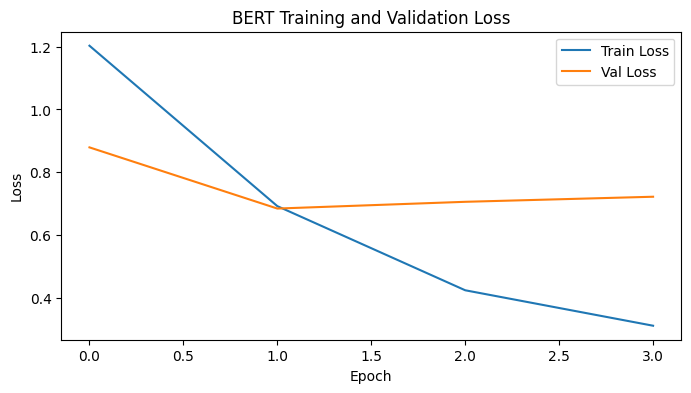

In [ ]:
# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


The training and validation loss curves for BERT show that while training loss decreased steadily across epochs, validation loss plateaued early and even slightly increased after the first epoch. This pattern suggests the model began overfitting after epoch 1, which is likely why early stopping was triggered. Although BERT was able to learn quickly, additional regularization or hyperparameter tuning might help improve its generalization on unseen lyrics.

